# Figures  
- Contains figures according to manuscripts

#### Import required packages

In [1]:
%reload_ext autoreload
%autoreload 2
from pathlib import Path
import glob
import pickle
import numpy as np
import pandas as pd
import umap
import pwlf
import statistics
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, linregress
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.DataUtils import DataUtils

#### Create objects to use utility functions

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


## Figure 2

In [3]:
# load data
df = reader.data_read_bz2("raw/FN/itr_200.bz2")

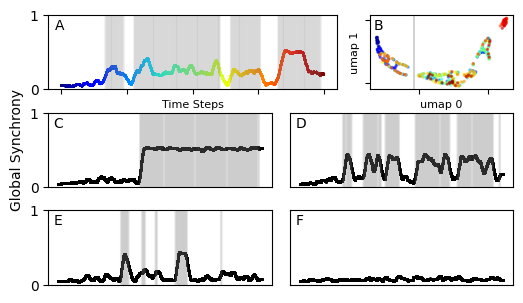

In [4]:
fig = plt.figure(figsize=([6,3.5]))
gs = gridspec.GridSpec(12, 12)
ax1 = plt.subplot(gs[0:4, 0:8])
# umap was trained on this iteration 136
# itr 136 of FN
_data = df[136].rolling(800, center=True).mean().ffill().bfill()
cmap = "jet"
with open("../../data/umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)
chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary
sep = -0.6
plt.subplots_adjust(hspace=18, wspace=0.8)
ax1.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax1.axvline(l, c="gray", alpha=0.1)
ax1.set_xlabel("Time Steps",fontsize=8)
ax1.set_ylim([0, 1])
ax1.text(0.025, 0.8, "A", transform=ax1.transAxes)
pos = ax1.get_position()
ax1.set_position([pos.x0, pos.y0, pos.width * 0.95, pos.height])


ax2 = plt.subplot(gs[0:4, 8:12])
# umap
ax2.scatter(
    embedding[:, 0], embedding[:, 1], s=2, c=range(len(chunks)), alpha=0.5, cmap=cmap
)
ax2.set_xlabel("umap 0",fontsize=8)
ax2.set_ylabel("umap 1",fontsize=8)
ax2.text(0.025, 0.8, "B", transform=ax2.transAxes)
ax2.axvline(sep, c="k", lw=0.25)


ax3 = plt.subplot(gs[4:8, 0:6])
ax3.xaxis.set_visible(False)
_data = df[39].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax3.scatter(_data.index, _data, c='black', s=1)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax3.axvline(l, c="gray", alpha=0.1)
ax3.set_ylabel('Global Synchrony',fontsize=10)
ax3.set_ylim([0, 1])
ax3.text(0.025, 0.8, "C", transform=ax3.transAxes)
ax3.yaxis.set_ticks([])


ax4 = plt.subplot(gs[4:8, 6:12], sharex=ax3, sharey=ax3)
ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)
_data = df[193].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax4.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax4.axvline(l, c="gray", alpha=0.1)
ax4.set_ylim([0, 1])
ax4.text(0.025, 0.8, "D", transform=ax4.transAxes)


ax5 = plt.subplot(gs[8:12, 0:6], sharex=ax3, sharey=ax3)
ax5.xaxis.set_visible(False)
_data = df[145].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax5.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax5.axvline(l, c="gray", alpha=0.1)
ax5.set_ylim([0, 1])
ax5.text(0.025, 0.8, "E", transform=ax5.transAxes)


ax6 = plt.subplot(gs[8:12, 6:12], sharex=ax3, sharey=ax3)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
_data = df[1].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax6.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax6.axvline(l, c="gray", alpha=0.1)
ax6.set_ylim([0, 1])
ax6.text(0.025, 0.8, "F", transform=ax6.transAxes)


plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

ax1.set_yticks([0,1])
ax1.set_yticklabels([0,1])
ax3.set_yticks([0,1])
ax3.set_yticklabels([0,1])
ax5.set_yticks([0,1])
ax5.set_yticklabels([0,1])

plt.savefig('../../data/results/figures/fig2_final.pdf',format='pdf')

Inspecting UMAP model parameters

In [5]:
# Inspect UMAP parameters
print("n_neighbors:", _u.n_neighbors)
print("n_components:", _u.n_components)
print("min_dist:", _u.min_dist)
print("metric:", _u.metric)

n_neighbors: 15
n_components: 2
min_dist: 0.1
metric: euclidean


# Figure 3

#### Read data from folder  
Reference notebook: "Analyse Calculate Final Params.ipynb"


In [6]:
# defining dictionaries for each parameter
# storing both partial and full transition data
# store standard deviation and manWhitney U test values

num_trans = {}
n_p = []
n_p_s = []
n_f = []
n_f_s = []

trans_time = {}
t_p = []
t_p_s = []
t_f = []
t_f_s = []
t_p_mw = []
t_f_mw = []

fp_time = {}
f_p = []
f_p_s = []
f_f = []
f_f_s = []
f_p_mw = []
f_f_mw = []

sync_time = {}
s_p = []
s_p_s = []
s_f = []
s_f_s = []
s_p_mw = []
s_f_mw = []

cov = {}
cov_p = []
cov_p_s = []
cov_f = []
cov_f_s = []
cov_p_mw = []
cov_f_mw = []

# 'fn' is initially used to label MMBN as stated in paper
# getting networks in ascending order
network_asc = [
    "fn",
    "mob",
    "lsc",
    "orb",
    "pir",
    "bla",
    "mrn",
    "re",
    "enti",
    "peri",
    "mos",
    "lha",
    "mop",
]
fn_data = reader.data_read_pkl("results/calculate_final_params/final_fn.pkl")

# uses manwhitney u test and stores p value
for nw in network_asc:
    params = reader.data_read_pkl(f"results/calculate_final_params/final_{nw}.pkl")
    # store number of transition
    n_p.append(params[0]["n_part"])
    n_f.append(params[0]["n_full"])
    n_p_s.append(np.sqrt(params[0]["n_part"]))
    n_f_s.append(np.sqrt(params[0]["n_full"]))

    # store transition time
    t_p_s.append(np.std(params[1]["t_t"]) / np.sqrt(len(params[1]["t_t"])))
    t_f_s.append(np.std(params[2]["t_t"]) / np.sqrt(len(params[2]["t_t"])))

    t_p.append(np.mean(params[1]["t_t"]))
    _, mw = mannwhitneyu(fn_data[1]["t_t"], params[1]["t_t"])
    t_p_mw.append(mw)
    t_f.append(np.mean(params[2]["t_t"]))
    _, mw = mannwhitneyu(fn_data[2]["t_t"], params[2]["t_t"])
    t_f_mw.append(mw)

    # store first passage time
    f_p_s.append(np.std(params[1]["fp_t"]) / np.sqrt(len(params[1]["fp_t"])))
    f_f_s.append(np.std(params[2]["fp_t"]) / np.sqrt(len(params[2]["fp_t"])))

    f_p.append(np.mean(params[1]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[1]["fp_t"], params[1]["fp_t"])
    f_p_mw.append(mw)
    f_f.append(np.mean(params[2]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[2]["fp_t"], params[2]["fp_t"])
    f_f_mw.append(mw)

    # Store sync time
    s_p_s.append(np.std(params[1]["s_t"]) / np.sqrt(len(params[1]["s_t"])))
    s_f_s.append(np.std(params[2]["s_t"]) / np.sqrt(len(params[2]["s_t"])))

    s_p.append(np.mean(params[1]["s_t"]))
    _, mw = mannwhitneyu(fn_data[1]["s_t"], params[1]["s_t"])
    s_p_mw.append(mw)
    s_f.append(np.mean(params[2]["s_t"]))
    _, mw = mannwhitneyu(fn_data[2]["s_t"], params[2]["s_t"])
    s_f_mw.append(mw)

    # store coverage
    # removing zero coverage values from partial transitions
    cov_part=params[1]["cov"]
    cov_part=[x for x in cov_part if x>0]
    cov_p_s.append(np.std(cov_part) / np.sqrt(len(cov_part)))
    cov_f_s.append(np.std(params[2]["cov"]) / np.sqrt(len(params[2]["cov"])))

    cov_p.append(np.mean(cov_part))
    fn_part_cov=[x for x in fn_data[1]["cov"] if x>0]
    _, mw = mannwhitneyu(fn_part_cov, cov_part)
    cov_p_mw.append(mw)
    cov_f.append(np.mean(params[2]["cov"]))
    _, mw = mannwhitneyu(fn_data[2]["cov"], params[2]["cov"])
    cov_f_mw.append(mw)

num_trans = {"n_p": n_p, "n_f": n_f, "n_p_s": n_p_s, "n_f_s": n_f_s}
trans_time = {
    "t_p": t_p,
    "t_f": t_f,
    "t_p_s": t_p_s,
    "t_f_s": t_f_s,
    "t_p_mw": t_p_mw,
    "t_f_mw": t_f_mw,
}
fp_time = {
    "f_p": f_p,
    "f_f": f_f,
    "f_p_s": f_p_s,
    "f_f_s": f_f_s,
    "f_p_mw": f_p_mw,
    "f_f_mw": f_f_mw,
}

sync_time = {
    "s_p": s_p,
    "s_f": s_f,
    "s_p_s": s_p_s,
    "s_f_s": s_f_s,
    "s_p_mw": s_p_mw,
    "s_f_mw": s_f_mw,
}

cov = {
    "cov_p": cov_p,
    "cov_f": cov_f,
    "cov_p_s": cov_p_s,
    "cov_f_s": cov_f_s,
    "cov_p_mw": cov_p_mw,
    "cov_f_mw": cov_f_mw,
}

In [7]:
a = ["num_trans"] * 2
b = ["trans_time"] * 6
c = ["fp_time"] * 6
d = ["sync_time"] * 6
e = ["cov"] * 6
upper_head = a + b + c + d + e

f = ["part", "full"]
g = ["part", "part_s", "part_mw", "full_mw", "full", "full_s"] * 4
lower_head = f + g

header = [upper_head, lower_head]
data = {
    ("num_trans", "part"): num_trans["n_p"],
    ("num_trans", "full"): num_trans["n_f"],
    ("num_trans", "part_s"): num_trans["n_p_s"],
    ("num_trans", "full_s"): num_trans["n_f_s"],
    ("trans_time", "part"): trans_time["t_p"],
    ("trans_time", "part_s"): trans_time["t_p_s"],
    ("trans_time", "part_mw"): trans_time["t_p_mw"],
    ("trans_time", "full"): trans_time["t_f"],
    ("trans_time", "full_s"): trans_time["t_f_s"],
    ("trans_time", "full_mw"): trans_time["t_p_mw"],
    ("fp_time", "part"): fp_time["f_p"],
    ("fp_time", "part_s"): fp_time["f_p_s"],
    ("fp_time", "part_mw"): fp_time["f_p_mw"],
    ("fp_time", "full"): fp_time["f_f"],
    ("fp_time", "full_s"): fp_time["f_f_s"],
    ("fp_time", "full_mw"): fp_time["f_p_mw"],
    ("sync_time", "part"): sync_time["s_p"],
    ("sync_time", "part_s"): sync_time["s_p_s"],
    ("sync_time", "part_mw"): sync_time["s_p_mw"],
    ("sync_time", "full"): sync_time["s_f"],
    ("sync_time", "full_s"): sync_time["s_f_s"],
    ("sync_time", "full_mw"): sync_time["s_p_mw"],
    ("cov", "part"): cov["cov_p"],
    ("cov", "part_s"): cov["cov_p_s"],
    ("cov", "part_mw"): cov["cov_p_mw"],
    ("cov", "full"): cov["cov_f"],
    ("cov", "full_s"): cov["cov_f_s"],
    ("cov", "full_mw"): cov["cov_f_mw"],
}

df_data = pd.DataFrame(data, index=network_asc)
df_data

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  0.945461   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  0.865168   
orb        136   94  11.661904   9.695360  53.057721  1.124891  0.157965   
pir        110   67  10.488088   8.185353  54.763636  1.241981  0.522551   
bla        107   51  10.344080   7.141428  54.188318  1.117801  0.985780   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  0.254302   
re         200   92  14.142136   9.591663  54.124500  0.763217  0.836102   
enti       151   57  12.288206   7.549834  53.687417  0.960022  0.481269   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.010906   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.040213   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.041488   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.036977   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  0.945461  ...  0.104380  351.034483  47.294445   
lsc   79.419588  1.289129  0.865168  ...  0.986182  311.785714  68.102203   
orb   82.572340  1.616342  0.157965  ...  0.960917  347.413793  32.158404   
pir   80.195522  1.615760  0.522551  ...  0.040085  399.047619  67.131559   
bla   80.609804  1.689315  0.985780  ...  0.610470  230.625000  28.823784   
mrn   78.601899  1.529340  0.254302  ...  0.791234  407.600000  58.272546   
re    77.778261  1.304602  0.836102  ...  0.504608  487.000000  70.648425   
enti  76.766667  1.499051  0.481269  ...  0.410884  399.722222  54.870038   
peri  79.453191  1.495899  0.010906  ...  0.006671  253.333333  28.349668   
mos   85.559524  2.795582  0.040213  ...  0.324357  268.125000  29.287603   
lha   78.384545  1.645938  0.041488  ...  0.013377  358.000000  83.694683   
mop   78.736111  1.935845  0.036977  ...  0.927616  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   0.104380  0.167642  0.008659  0.750962  0.546801  0.007664  0.359165  
lsc   0.986182  0.186380  0.006779  0.348070  0.570075  0.006157  0.201947  
orb   0.960917  0.147165  0.008332  0.024119  0.526395  0.008266  0.009647  
pir   0.040085  0.167115  0.009095  0.737818  0.540389  0.008939  0.137276  
bla   0.610470  0.199997  0.010300  0.107743  0.582879  0.008483  0.028932  
mrn   0.791234  0.172446  0.007612  0.979731  0.518023  0.008323  0.000557  
re    0.504608  0.189600  0.007044  0.183253  0.546913  0.007366  0.338564  
enti  0.410884  0.172499  0.007728  0.775876  0.556293  0.008835  0.951700  
peri  0.006671  0.155180  0.010715  0.159732  0.570277  0.009150  0.288445  
mos   0.324357  0.156893  0.007194  0.120168  0.558530  0.010439  0.890791  
lha   0.013377  0.172548  0.006927  0.761627  0.514550  0.009643  0.000635  
mop   0.927616  0.150628  0.007123  0.041466  0.536189  0.007992  0.068637  

[13 rows x 28 columns]

#### corrected p values using Holm-Bonnferroni correction

In [8]:
# Identify all target p-value columns ending in '_mw'
mw_columns = [col for col in df_data.columns if col[1].endswith('_mw')]

# Iterate and replace in-place ---
for col in mw_columns:
    # Extract the raw p-values for the current column
    raw_p_values = df_data[col].values
    
    # Apply Holm-Bonferroni correction (Family-Wise Error Rate alpha=0.05)
    _, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')
    
    # Overwrite the original column with the corrected values
    df_data[col] = corrected_p_values

# Verification Check
print(f"Original Shape: {df_data.shape} -> Current Shape: {df_data.shape}")


Original Shape: (13, 28) -> Current Shape: (13, 28)


In [9]:
df_data

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  1.000000   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  1.000000   
orb        136   94  11.661904   9.695360  53.057721  1.124891  1.000000   
pir        110   67  10.488088   8.185353  54.763636  1.241981  1.000000   
bla        107   51  10.344080   7.141428  54.188318  1.117801  1.000000   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  1.000000   
re         200   92  14.142136   9.591663  54.124500  0.763217  1.000000   
enti       151   57  12.288206   7.549834  53.687417  0.960022  1.000000   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.141772   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.443728   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.443728   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.443728   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  1.000000  ...  1.000000  351.034483  47.294445   
lsc   79.419588  1.289129  1.000000  ...  1.000000  311.785714  68.102203   
orb   82.572340  1.616342  1.000000  ...  1.000000  347.413793  32.158404   
pir   80.195522  1.615760  1.000000  ...  0.440930  399.047619  67.131559   
bla   80.609804  1.689315  1.000000  ...  1.000000  230.625000  28.823784   
mrn   78.601899  1.529340  1.000000  ...  1.000000  407.600000  58.272546   
re    77.778261  1.304602  1.000000  ...  1.000000  487.000000  70.648425   
enti  76.766667  1.499051  1.000000  ...  1.000000  399.722222  54.870038   
peri  79.453191  1.495899  0.141772  ...  0.086728  253.333333  28.349668   
mos   85.559524  2.795582  0.443728  ...  1.000000  268.125000  29.287603   
lha   78.384545  1.645938  0.443728  ...  0.160528  358.000000  83.694683   
mop   78.736111  1.935845  0.443728  ...  1.000000  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   1.000000  0.167642  0.008659  1.000000  0.546801  0.007664  1.000000  
lsc   1.000000  0.186380  0.006779  1.000000  0.570075  0.006157  1.000000  
orb   1.000000  0.147165  0.008332  0.313549  0.526395  0.008266  0.106112  
pir   0.440930  0.167115  0.009095  1.000000  0.540389  0.008939  1.000000  
bla   1.000000  0.199997  0.010300  1.000000  0.582879  0.008483  0.289324  
mrn   1.000000  0.172446  0.007612  1.000000  0.518023  0.008323  0.007235  
re    1.000000  0.189600  0.007044  1.000000  0.546913  0.007366  1.000000  
enti  1.000000  0.172499  0.007728  1.000000  0.556293  0.008835  1.000000  
peri  0.086728  0.155180  0.010715  1.000000  0.570277  0.009150  1.000000  
mos   1.000000  0.156893  0.007194  1.000000  0.558530  0.010439  1.000000  
lha   0.160528  0.172548  0.006927  1.000000  0.514550  0.009643  0.007615  
mop   1.000000  0.150628  0.007123  0.497591  0.536189  0.007992  0.617734  

[13 rows x 28 columns]

Extract useful data from dataframe

In [10]:
df_dum=df_data.copy()
num_trans=df_dum[("num_trans","full")].to_list()
trans_time=df_dum[("trans_time","full")].to_list()
cov=df_dum[("cov","full")].to_list()
cov_part=df_dum[("cov","part")].to_list()

Extract network which are significant wrt FN

In [11]:
# find index of significant transition time
t_mw=df_dum[("trans_time","full_mw")]
t_mw_sig=t_mw[t_mw<0.05].index.to_list()
t_mw_l=df_dum[("trans_time","full_mw")].to_list() 
t_m_s=[id for id,x in enumerate(t_mw_l) if x<0.05] #id
# names of significant network
t_m_l=[network_asc[x] for x in t_m_s]


# find significant coverage
cov_mw=df_dum[('cov','full_mw')]
c_mw_sig=cov_mw[cov_mw<0.05].index.to_list()
c_mw_l=df_dum[('cov','full_mw')].to_list() # names of significant networks
c_m_s=[id for id,x in enumerate(c_mw_l) if x<0.05] # id 
c_m_l=[network_asc[x] for x in c_m_s]




Applying Poisson test for number of transitions

In [12]:


mmbn_full = df_dum['num_trans']['full']['fn']
nepochs = 40000

# Arrays to gather loop data
network_labels = []
network_indices = []
raw_p_values = []
stat_values = []

# --- 1. Collect Poisson test results across all parallel candidate networks ---
# Starting from index 1 to skip 'fn' as the baseline automatically
for n, nw in enumerate(df_dum.index):
    if nw == 'fn':
        continue
    
    s, p = scipy.stats.poisson_means_test(
        df_dum['num_trans']['full'][nw], nepochs, 
        mmbn_full, nepochs
    )
    
    network_labels.append(nw)
    network_indices.append(n)
    stat_values.append(s)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant and Insignificant Lists ---
snw = []     # Significant network names
inw = []     # Insignificant network names
snw_in = []  # Significant network index positions 
inw_in = []  # Insignificant network index positions

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Stat (S)':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, idx, stat, raw_p, corr_p, is_significant in zip(network_labels, network_indices, stat_values, raw_p_values, corrected_p_values, reject):
    print(f"{label:<15} | {stat:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    if is_significant:
        snw.append(label)
        snw_in.append(idx)
    else:
        inw.append(label)
        inw_in.append(idx)

print("\n--- Summary Results ---")
print(f"Significant Networks (snw): {snw}")
print(f"Significant Indices (snw_in): {snw_in}")
print(f"Insignificant Networks (inw): {inw}")
print(f"Insignificant Indices (inw_in): {inw_in}")

Network Label   | Stat (S)   | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
mob             | -0.6412    | 5.2326e-01   | 1.0000e+00   | False       
lsc             | -0.4243    | 6.7361e-01   | 1.0000e+00   | False       
orb             | -0.6412    | 5.2326e-01   | 1.0000e+00   | False       
pir             | -2.7611    | 5.6630e-03   | 3.9641e-02   | True        
bla             | -4.1903    | 2.4345e-05   | 2.4345e-04   | True        
mrn             | -1.7790    | 7.5121e-02   | 3.7560e-01   | False       
re              | -0.7877    | 4.3258e-01   | 1.0000e+00   | False       
enti            | -3.6366    | 2.6436e-04   | 2.1149e-03   | True        
peri            | -4.5724    | 3.8381e-06   | 4.2219e-05   | True        
mos             | -5.0658    | 2.8007e-07   | 3.3609e-06   | True        
lha             | -3.8187    | 1.2182e-04   | 1.0963e-03   | True        
mop             | -2.3434    | 1.9071e-

#### Taking those FPT and ST values which corresponds to slope 1 of fitted ST and FPT to exponential
- Data stored in results folder as: 
- ST: '../../results/st_slop1_val_full.pkl' and 
- FPT: '../../results/fpt_slop1_val_full.pkl

FPT correspomding to slope 1  
- mean
- mw

In [31]:
# fpt_data=reader.data_read_pkl('results/fpt_slop1_val_full.pkl')
# # sort in desired order key
# fpt_data={key:fpt_data[key] for key in network_asc}
# fpt_mean=[]
# fpt_mw=[]
# for nw in network_asc:
#     fpt_mean.append(np.mean(fpt_data[nw]))
#     _,mw=mannwhitneyu(fpt_data['fn'],fpt_data[nw])
#     fpt_mw.append(mw)
    
# # index of significant nw
# f_m_s=[id for id,x in enumerate(fpt_mw) if x<0.05]
# # name of significant network
# f_m_l=[network_asc[x] for x in f_m_s]

fpt_data = reader.data_read_pkl('results/fpt_slop1_val_full.pkl')
# sort in desired order key
fpt_data = {key: fpt_data[key] for key in network_asc}

fpt_mean = []
fpt_mw = []  # Will store the uncorrected p-values

for nw in network_asc:
    fpt_mean.append(np.mean(fpt_data[nw]))
    _, mw = mannwhitneyu(fpt_data['fn'], fpt_data[nw])
    fpt_mw.append(mw)

# --- HOLM-BONFERRONI CORRECTION ---
# 'holm' performs the Holm-Bonferroni step-down procedure.
# corrected_pvals holds the adjusted p-values.
reject, corrected_pvals, _, _ = multipletests(fpt_mw, alpha=0.05, method='holm')
    
# index of significant nw (using corrected p-values)
f_m_s = [id for id, p_val in enumerate(corrected_pvals) if p_val < 0.05]

# name of significant network
f_m_l = [network_asc[x] for x in f_m_s]

ST corresponding to slope 1 but taking slope 2 of FN (as it's slope 1 only considers 3 datapoints)

In [ ]:
st_data=reader.data_read_pkl('results/st_slop1_val_full.pkl')
st_data

In [33]:
st_data=reader.data_read_pkl('results/st_slop1_val_full.pkl')
st_data_slp_2=reader.data_read_pkl('results/st_slop2_val_full.pkl')
# chnage FN data according to slope 2
st_data['fn']=st_data_slp_2['fn'].copy()
# sort in desired order key
st_data={key:st_data[key] for key in network_asc}
st_mean=[]
st_mw=[]
for nw in network_asc:
    st_mean.append(np.mean(st_data[nw]))
    _,mw=mannwhitneyu(st_data['fn'],st_data[nw])
    st_mw.append(mw)
    
# index of significant nw
s_m_s=[id for id,x in enumerate(st_mw) if x<0.05]
# name of significant network
s_m_l=[network_asc[x] for x in s_m_s]

In [34]:
s_m_s

[]

Find out which coverage distribution looks not confusing wrt FN  
- seems orb is best

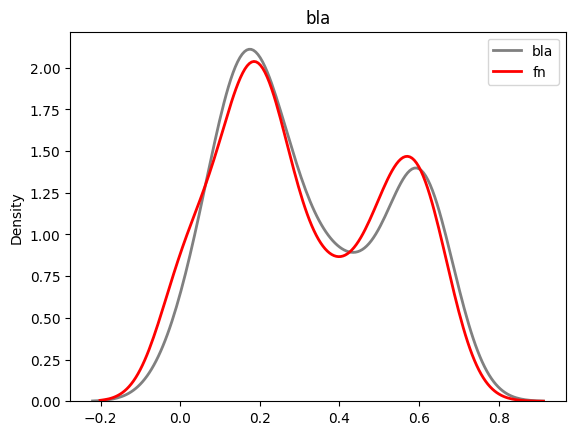

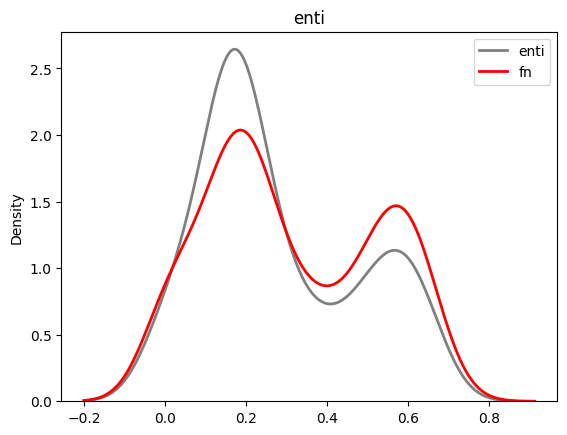

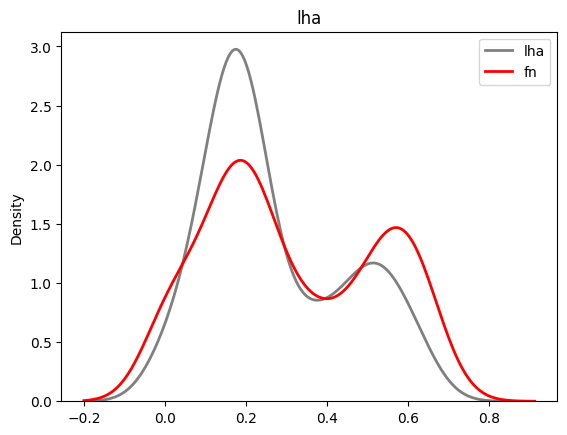

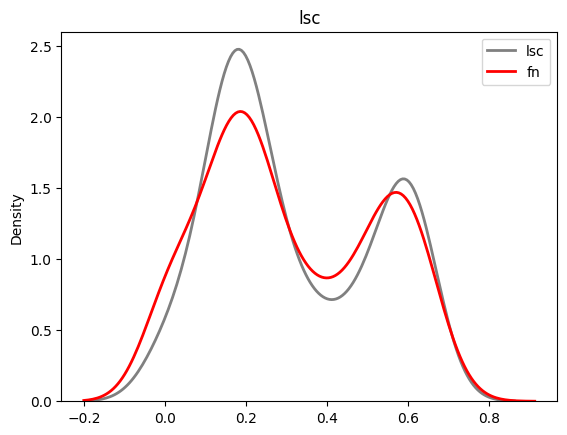

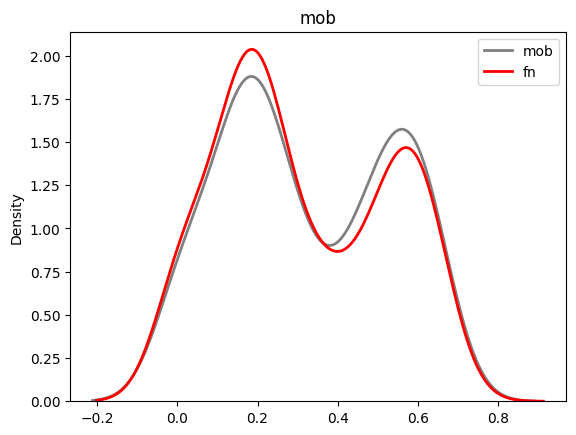

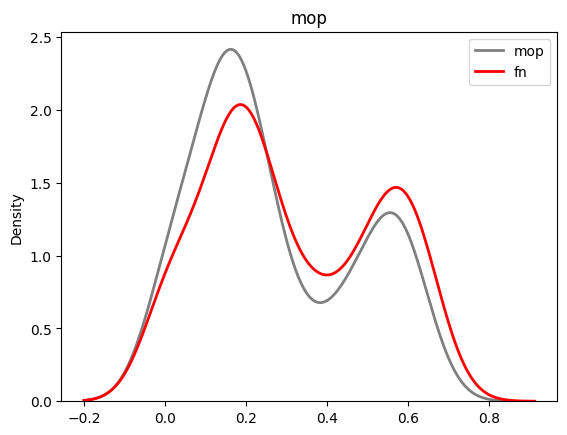

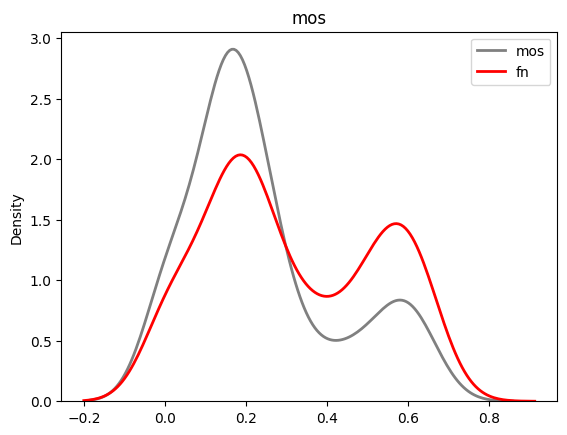

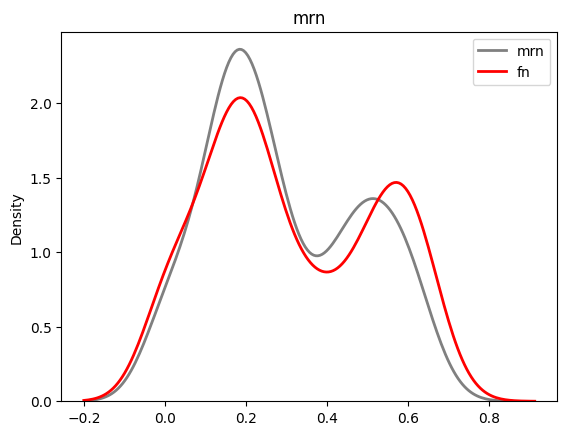

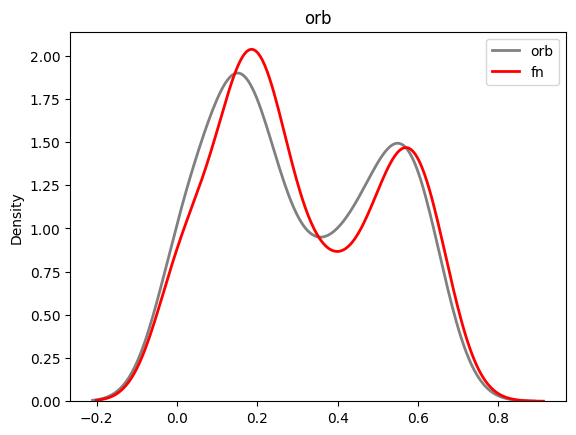

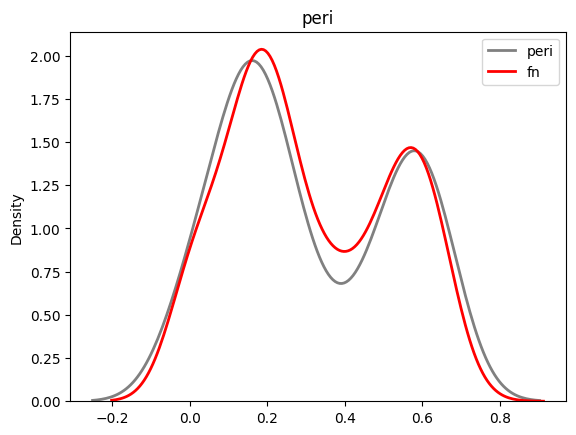

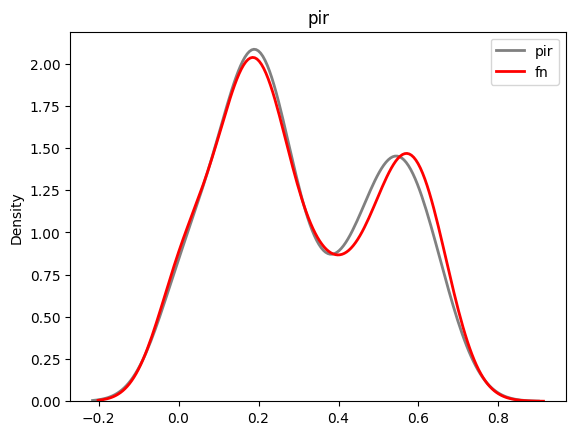

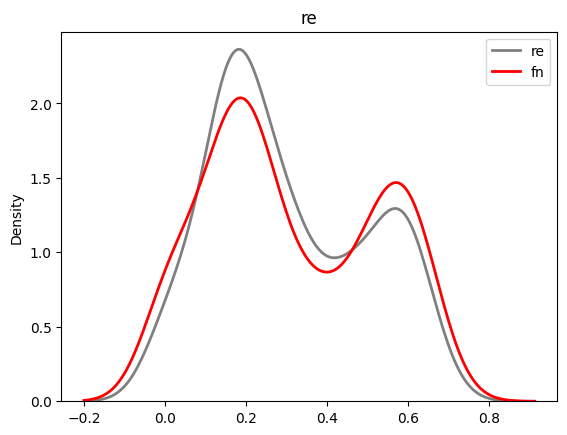

In [35]:
# getting  transition coverage data
nw = ['bla', 'enti', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']

for i in nw:
    a_data=reader.data_read_pkl(f'results/calculate_final_params/final_{i}.pkl')
    a_fcov=a_data[2]['cov']
    a_pcov=a_data[1]['cov']
    a_pcov=[x for x in a_pcov if x>0]
    a_cov=a_fcov+a_pcov

    
    plt.figure()
    sns.kdeplot(a_cov,color='grey',linewidth=2,label=i)
    fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
    fn_fcov=fn_data[2]['cov']
    fn_pcov=fn_data[1]['cov']
    fn_pcov=[x for x in fn_pcov if x>0]
    fn_cov=fn_fcov+fn_pcov
    sns.kdeplot(fn_cov,color='red',linewidth=2,label='fn')
    plt.title(i)
    plt.legend()

####  Take figure layout 

Text(-0.175, 1.2, 'C')

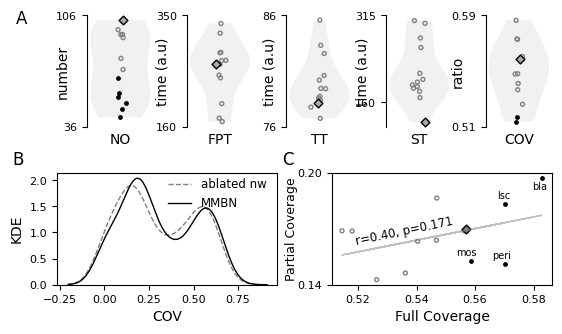

In [36]:
fig=plt.figure(figsize=(6,3.5))
gs=gridspec.GridSpec(11,14,wspace=2.5,hspace=3) #10 rows, 15 columns

# fig 3A
# make 5 plots inside 
sub_gs = gs[0:5, :].subgridspec(1, 5, wspace=0.5)

#NO
ax0 = fig.add_subplot(sub_gs[0])
ax0.set_xticks([]) # hide tick labels
ax0.set_xlabel('NO')
ax0.set_ylabel('number', fontsize=10,labelpad=-10)
# Violin plot of fpt mean in light shade
violin_parts=ax0.violinplot(num_trans,positions=[1],showextrema=False,showmeans=False,showmedians=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    # pc.set_edgecolor('None')
    pc.set_alpha(0.3)
# get jittered x
x_jitter = np.random.normal(loc=1.0,scale=0.03,size=13)
# not significant networks
y_nsgno=[num_trans[x] for x in inw_in]
x_nsgno=[x_jitter[x] for x in inw_in]
ax0.scatter(x_nsgno,y_nsgno,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
# dark significant networks
y_no=[num_trans[x] for x in snw_in]
x_no=[x_jitter[x] for x in snw_in]
ax0.scatter(x_no,y_no,s=6,zorder=2,c='k')
# for MMBN
ax0.scatter(x_jitter[0],num_trans[0],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
# get current y limits
ymin, ymax = ax0.get_ylim()
# set ticks at first and last positions
ax0.set_yticks([36, 106])
ax0.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax0.tick_params(axis='y', labelsize=8)



#FPT
ax1=fig.add_subplot(sub_gs[1])
ax1.set_xticks([])
ax1.set_ylabel('time (a.u)', fontsize=10, labelpad=-10)
ax1.set_xlabel('FPT')
# Violin plot of fpt mean in light shade
violin_parts=ax1.violinplot(fpt_mean,positions=[1],showextrema=False,showmeans=False,showmedians=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    # pc.set_edgecolor('None')
    pc.set_alpha(0.3)
# get jittered x
x_jitter = np.random.normal(loc=1.0,scale=0.03,size=13)
# not significant networks
n_sg_fpt=list(set(list(range(1,13)))-set(f_m_s))
y_nsgfpt=[fpt_mean[x] for x in n_sg_fpt]
x_nsgfpt=[x_jitter[x] for x in n_sg_fpt]
ax1.scatter(x_nsgfpt,y_nsgfpt,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
# dark significant nw
y_fpt=[fpt_mean[x] for x in f_m_s ]
x_fpt =[x_jitter[x] for x in f_m_s]
ax1.scatter(x_fpt,y_fpt,s=6,zorder=2,c='k')
# plot FN
ax1.scatter(x_jitter[0],fpt_mean[0],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
# get current y limits
ymin, ymax = ax1.get_ylim()
# set ticks at first and last positions
ax1.set_yticks([160, 350])
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax1.tick_params(axis='y', labelsize=8)



#TT
ax2=fig.add_subplot(sub_gs[2])
ax2.set_xticks([])
ax2.set_ylabel('time (a.u)', fontsize=10,labelpad=-10)
ax2.set_xlabel('TT')
# Violin plot of trans time in light shade
violin_parts=ax2.violinplot(trans_time,positions=[1],showextrema=False,showmeans=False,showmedians=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    # pc.set_edgecolor('None')
    pc.set_alpha(0.3)
# get jittered x
x_jitter = np.random.normal(loc=1.0,scale=0.03,size=13)
# not significant networks
n_sg_tt=list(set(list(range(1,13)))-set(t_m_s))
y_nsgtt=[trans_time[x] for x in n_sg_tt]
x_nsgtt=[x_jitter[x] for x in n_sg_tt]
ax2.scatter(x_nsgtt,y_nsgtt,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
# dark significant nw
y_tt=[trans_time[x] for x in t_m_s ]
x_tt=[x_jitter[x] for x in t_m_s]
ax2.scatter(x_tt,y_tt,s=6,zorder=2,c='k')
#plot FN
ax2.scatter(x_jitter[0],trans_time[0],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
# get current y limits
ymin, ymax = ax2.get_ylim()
# set ticks at first and last positions
ax2.set_yticks([76, 86])
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2.tick_params(axis='y', labelsize=8)



#ST
ax3=fig.add_subplot(sub_gs[3])
ax3.set_xticks([])
ax3.set_ylabel('time (a.u)',fontsize=10,labelpad=-10)
ax3.set_xlabel('ST')
# Violin plot of sync time mean in light shade
violin_parts=ax3.violinplot(st_mean,positions=[1],showextrema=False,showmeans=False,showmedians=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    # pc.set_edgecolor('None')
    pc.set_alpha(0.3)
# get jittered x
x_jitter = np.random.normal(loc=1.0,scale=0.03,size=13)
# not significant networks
n_sg_st=list(set(list(range(1,13)))-set(s_m_s))
y_nsgst=[st_mean[x] for x in n_sg_st]
x_nsgst=[x_jitter[x] for x in n_sg_st]
ax3.scatter(x_nsgst,y_nsgst,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
# dark significant nw
y_st=[st_mean[x] for x in s_m_s ]
x_st=[x_jitter[x] for x in s_m_s]
ax3.scatter(x_st,y_st,s=6,zorder=2,c='k')
#plot FN
ax3.scatter(x_jitter[0],st_mean[0],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
# get current y limits
ymin, ymax = ax3.get_ylim()
# set ticks at first and last positions
ax3.set_yticks([160, 315])
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax3.tick_params(axis='y', labelsize=8)


#COV
ax4=fig.add_subplot(sub_gs[4])
ax4.set_xticks([])
ax4.set_ylabel('ratio',fontsize=10,labelpad=-10)
ax4.set_xlabel('COV')
# Violin plot of coverage in light shade
violin_parts=ax4.violinplot(cov,positions=[1],showextrema=False,showmeans=False,showmedians=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    # pc.set_edgecolor('None')
    pc.set_alpha(0.3)
# get jittered x
x_jitter = np.random.normal(loc=1.0,scale=0.03,size=13)
# not significant networks
n_sg_cv=list(set(list(range(1,13)))-set(c_m_s))
y_nsgcv=[cov[x] for x in n_sg_cv]
x_nsgcv=[x_jitter[x] for x in n_sg_cv]
ax4.scatter(x_nsgcv,y_nsgcv,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
# dark significant nw
y_cv=[cov[x] for x in c_m_s ]
x_cv=[x_jitter[x] for x in c_m_s]
ax4.scatter(x_cv,y_cv,s=6,zorder=2,c='k')
#plot FN
ax4.scatter(x_jitter[0],cov[0],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
# get current y limits
ymin, ymax = ax4.get_ylim()
# set ticks at first and last positions
ax4.set_yticks([ymin, ymax])
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# optionally format them (e.g. integers, smaller font)
ax4.tick_params(axis='y', labelsize=8)

# hide spines
for ax in [ax0,ax1,ax2,ax3,ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)



#fig 3B
# plot coverage in comparison to FN
# choose network which looks cool
ax5=fig.add_subplot(gs[6:11,0:7])
# ax5.set_yticklabels([])
# ax5.set_xticklabels([])
ax5.tick_params(axis='y', labelsize=8)
ax5.tick_params(axis='x', labelsize=8)
ax5.set_xlabel("COV")
# shift this to left for more space
pos = ax5.get_position()
ax5.set_position([pos.x0-0.05,pos.y0,pos.width,pos.height])

# choosing ORB as it will look best
# combining coverage of both FN and ablated nw so that it looks bimodal
a_data=reader.data_read_pkl(f'results/calculate_final_params/final_orb.pkl')
a_fcov=a_data[2]['cov']
a_pcov=a_data[1]['cov']
a_pcov=[x for x in a_pcov if x>0]
a_cov=a_fcov+a_pcov
sns.kdeplot(a_cov,ax=ax5,color='grey',linewidth=1,label='ablated nw',linestyle='--')
# read full network data
fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
fn_fcov=fn_data[2]['cov']
fn_pcov=fn_data[1]['cov']
fn_pcov=[x for x in fn_pcov if x>0]
fn_cov=fn_fcov+fn_pcov
sns.kdeplot(fn_cov,ax=ax5,color='k',linewidth=1,label='MMBN')
ax5.legend(loc="upper right",fontsize=8.5,frameon=False,bbox_to_anchor=(1, 1.05))
ax5.set_ylabel("KDE")




#fig 3C
# scatter plot of avg partial and full transition coverage
ax6=fig.add_subplot(gs[6:11,7:14])
# ax6.set_yticklabels([])
# ax6.set_xticklabels([])
ax6.set_xlabel("Full Coverage")
ax6.set_ylabel("Partial Coverage",fontsize =9,labelpad=0)
# ax6.scatter(cov[1:],cov_part[1:],s=6,c='darkgray')
# ax6.scatter(cov[0],cov_part[0],c='k',s=8,marker='D')
# dark significant nw are right of MMBN
cov_s=[]
for name in ['mos','peri','lsc','bla']:
    {
        cov_s.append(network_asc.index(name))
    }
n_sg_cv=list(set(list(range(1,13)))-set(cov_s))
x_nsgcv=[cov[x] for x in n_sg_cv]
y_nsgcv=[cov_part[x] for x in n_sg_cv]
ax6.scatter(x_nsgcv,y_nsgcv,s=8,edgecolors='gray',facecolors='none', marker='o')

x_cv=[cov[x] for x in cov_s ]
y_cv=[cov_part[x] for x in cov_s]
ax6.scatter(x_cv,y_cv,s=6,zorder=2,c='k')
# annotate networks right of MMBN

for name in['mos','peri','lsc','bla']:
    x=network_asc.index(name)# Get the network name
    xi = cov[x]                # x-coordinate (Full Coverage)
    yi = cov_part[x]           # y-coordinate (Partial Coverage)

    if name=='bla':
        ax6.annotate(
            name, 
            xy=(xi, yi),           # The point to annotate
            xytext=(4, -8),         # Offset text by 4 points right and 4 points up
            textcoords="offset points", 
            fontsize=7,            # Keep it small so it doesn't clutter the panel
            color='black',
            ha='right',             # Horizontally align text to the left of the offset
        )
    else:
        ax6.annotate(
            name, 
            xy=(xi, yi),           # The point to annotate
            xytext=(4, 4),         # Offset text by 4 points right and 4 points up
            textcoords="offset points", 
            fontsize=7,            # Keep it small so it doesn't clutter the panel
            color='black',
            ha='right',             # Horizontally align text to the left of the offset
        )

# #plot FN
ax6.scatter(cov[0],cov_part[0],c='gray',s=20,marker='D',edgecolors='k')

# fit straight line
coeffs=np.polyfit(cov,cov_part,deg=1)
slope,intercept=coeffs
y_fit=slope*np.array(cov)+intercept
#pearson correlation
corr,pval =pearsonr(cov,cov_part)
#plot fit line
ax6.plot(cov,y_fit,color='grey',linewidth=1, alpha=0.5)
# annotate over line
x_mid=np.mean(cov)+0.005
y_mid=slope*x_mid+intercept-0.008
angle=np.degrees(np.arctan(slope))-5
ax6.text(x_mid,y_mid,f"r={corr:.2f}, p={pval:.3f}",
         fontsize=8.5,color='black', rotation=angle,
         ha="right",va="bottom")
# get current y limits
ymin, ymax = ax6.get_ylim()
# set ticks at first and last positions
ax6.set_yticks([ymin, ymax])
ax6.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# optionally format them (e.g. integers, smaller font)

ax6.tick_params(axis='y', labelsize=8)
ax6.tick_params(axis='x', labelsize=8)

#panel A
ax0.text(-0.9, 1.05, "A", transform=ax0.transAxes,
         fontsize=12, va="top", ha="right")

# Panel B
ax5.text(-0.15, 1.2, "B", transform=ax5.transAxes,
         fontsize=12, va="top", ha="right")

# Panel C
ax6.text(-0.175, 1.2, "C", transform=ax6.transAxes,
         fontsize=12, va="top", ha="right")



# Figure 4
- use 'Analyse Cluster Backtrack.ipynb' notebook  
A. results/figures/fig4a_data.pkl  
B. results/figures/fig4b_data.pkl as dataframe 'bz2' compression  
C. results/figures/fig4c_data.pkl as dataframe 'bz2' compression  
D. results/figures/fig4d_data.pkl as dataframe 'bz2' compression  


Data for figure 4:  

/tmp/ipykernel_300671/3596220541.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(df_sorted.index,fontsize=8.5)


Text(-0.08, 1.2, 'D')

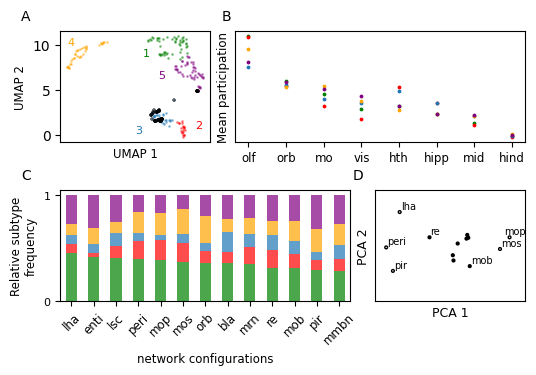

In [39]:
fig=plt.figure(figsize=(6,3.5))
gs=gridspec.GridSpec(11,14,wspace=2.5,hspace=5) #10 rows, 14 columns

# 4A
# plot umap of FN
ax1=fig.add_subplot(gs[0:5,0:5])
ax1.set_xticks([])
colors = {0: "green", 1: "red", 2: "C0",3:"orange",4:"purple"}
data_a=reader.data_read_pkl('results/figures/fig4a_data.pkl')
for cluster_id in np.unique(data_a['lbl']):
    cluster_points =data_a['we'][data_a['lbl'] == cluster_id]
    ax1.scatter(cluster_points[:,0], cluster_points[:,1],
                c=colors[cluster_id], s=1, alpha=0.4)

x=data_a['fe'][:,0]
y=data_a['fe'][:,1]
ax1.scatter(x,y, 
            s=10,marker='+',c='k',alpha=0.5)
ax1.set_xlabel('UMAP 1', fontsize=8.5)
ax1.set_ylabel('UMAP 2', fontsize=8.5)
#label red cluster as 1
ax1.text(0.55, 0.8, "1",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='green')
#label green cluster as 2
ax1.text(0.9, 0.15, "2",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='red')
#label blue cluster as 3
ax1.text(0.5, 0.1, "3",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='C0')
#label orange cluster as 4
ax1.text(0.05, 0.9, "4",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='orange')
# label cyan cluster as 5
ax1.text(0.65, 0.6, "5",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='purple')

#4C
# plot ratio of points in cluster to total points in cluster
ax3=fig.add_subplot(gs[6:11,0:9])
ax3.set_xticks([])
data_b=reader.data_read_bz2('results/figures/fig4b_data.pkl')
data_b=data_b.rename(columns={"fn": "mmbn"}).T
# order by decreasing value of green
data_b=data_b.sort_values(by=0,ascending=False)
data_b.plot(kind='bar',color=colors,ax=ax3, stacked=True,alpha=0.7,fontsize=8)
ax3.legend().set_visible(False)
ax3.set_xticklabels(data_b.index, fontsize=8.5,rotation=45)
ax3.set_ylabel('Relative subtype\nfrequency', fontsize=8.5)
ymin,ymax=ax3.get_ylim()
ax3.set_yticks([0,1])
ax3.set_xlabel('network configurations',fontsize=8.5)

#4B
# plot mean participation across newtorks wrt community
ax2=fig.add_subplot(gs[0:5,5:14])
ax2.set_yticks([])
data_c = reader.data_read_pkl('results/figures/fig4c_data.pkl')
df_m=pd.DataFrame()
for df in data_c:
    df=df.mean(axis=0).T
    df_m=pd.concat([df_m,df],axis=1)
df_m.columns=[0,1,2,3,4]
df_sorted=df_m.sort_values(by=4,ascending = False)
for n,r in enumerate(df_sorted.columns):
    ax2.scatter(df_sorted.index, df_sorted[n], color=colors[n],s=3,marker='o')
ax2.set_xticklabels(df_sorted.index,fontsize=8.5)
ax2.set_ylabel('Mean participation',fontsize=8.5)


#4D
ax4=fig.add_subplot(gs[6:11,9:14])
ax4.set_xticks([])
ax4.set_yticks([])
data_d = reader.data_read_bz2('results/figures/fig4d_data.pkl')
nw_lbl = list(data_d.index)
#applying pca to reduce 13x40 to 13x2
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(data_d.values)
clu_tf_pca=reducer_pca.transform(data_d.values)
#apply kmeans
kmeans_pl = KMeans(n_clusters=4, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)
colors_bw = ['black','white','black','white']  # assign manually
ax4.scatter(clu_tf_pca[:,0], clu_tf_pca[:,1],
            c=[colors_bw[i] for i in clus_pl],
            s=4, edgecolors='black')

for i, label in enumerate(nw_lbl):
    if label=='lsc' or label=='mrn' or label=='fn' or label == 'orb' or label=='enti' or label=='bla':
        continue
    elif label=='mop':
        ax4.text(clu_tf_pca[i,0]-0.1, clu_tf_pca[i,1]+0.08, label, fontsize=7)
    else:
        ax4.text(clu_tf_pca[i,0]+0.02, clu_tf_pca[i,1]+0.08, label, fontsize=7)
ax4.set_xlim(-1.5,1.5)
ax4.set_ylim(-1.5,1.5)
ax4.set_xlabel('PCA 1',fontsize=9)
ax4.set_ylabel('PCA 2',fontsize=9)

#panel A
ax1.text(-0.2, 1.2, "A", transform=ax1.transAxes,
         fontsize=10, va="top", ha="right")
# Panel B
ax2.text(-0.015, 1.2, "B", transform=ax2.transAxes,
         fontsize=10, va="top", ha="right")
# Panel C
ax3.text(-0.1, 1.2, "C", transform=ax3.transAxes,fontsize=10, va="top", ha="right")
#panel D
ax4.text(-0.08, 1.2, "D", transform=ax4.transAxes,
         fontsize=10, va="top", ha="right")

#### Fig 4d analysis

Let's reduce from 40x13 to 40x2

In [40]:
data_d=reader.data_read_bz2('results/figures/fig4d_data.pkl')
data_d=data_d.T
data_d

bla      enti        fn       lha       lsc       mob       mop  \
0 mo    0.946027  1.257179  0.993989  1.093092  1.002861  0.979523  0.821761   
  vis   0.790222  0.599361  0.678284  0.685441  0.575773  0.712642  0.610196   
  orb   1.315748  1.439222  1.416082  1.320350  1.367462  1.321307  1.240884   
  hth   0.679832  0.661568  0.684669  0.570927  0.706469  0.873694  0.723040   
  olf   2.293980  2.186557  2.423625  2.502703  2.547664  2.101735  2.778786   
  hipp  0.569710  0.454208  0.511457  0.512058  0.492780  0.639470  0.538973   
  mid   0.404481  0.401906  0.291894  0.315430  0.306991  0.371628  0.286359   
  hind  0.030669  0.041159  0.019842  0.024017  0.024914  0.030643  0.015224   
1 mo    0.769758  1.039782  0.691751  0.910082  0.808391  0.671688  0.692878   
  vis   0.501367  0.434212  0.350546  0.345501  0.417801  0.453883  0.412196   
  orb   1.226298  1.296519  1.160095  1.255120  1.219213  1.217870  1.210980   
  hth   1.088579  1.078109  1.253793  1.027692  1.091156  1.290179  1.120101   
  olf   2.172672  2.136320  2.372702  2.665567  2.546907  2.266131  2.478137   
  hipp  0.823720  0.676834  0.921665  0.602992  0.660218  0.840573  0.790906   
  mid   0.417606  0.338224  0.249447  0.193046  0.256316  0.259676  0.294803   
  hind  0.035614  0.029771  0.012751  0.009637  0.014346  0.008337  0.012912   
2 mo    0.849109  1.002468  0.866573  0.977224  0.931786  0.906451  0.866434   
  vis   0.792732  0.864940  0.729693  0.969387  0.881706  0.754352  0.953976   
  orb   1.226711  1.315511  1.252922  1.223367  1.223441  1.206358  1.213763   
  hth   1.104788  0.966488  1.120338  0.957320  1.026551  1.165951  1.085205   
  olf   1.553973  1.495331  1.719729  1.550775  1.594622  1.623808  1.759929   
  hipp  0.911578  0.744301  0.846309  0.747706  0.774398  0.845394  0.640850   
  mid   0.561109  0.610961  0.464436  0.574222  0.567495  0.497687  0.479844   
  hind  0.043477  0.029240  0.024531  0.024792  0.036780  0.026126  0.027235   
3 mo    0.985605  1.004823  1.116521  1.991334  1.141416  0.900731  0.938163   
  vis   0.801969  0.658080  0.757281  1.102490  0.671139  1.005166  0.403518   
  orb   1.043503  1.211021  1.416599  1.353937  1.359959  0.823657  1.199476   
  hth   0.852318  0.813082  0.548796  0.294111  0.672820  0.721548  0.738037   
  olf   2.075228  2.073091  2.168640  1.227007  2.263755  2.564071  2.974656   
  hipp  0.654320  0.724426  0.617401  0.477774  0.575472  0.536216  0.554137   
  mid   0.587057  0.515478  0.374762  0.553347  0.315441  0.448612  0.192013   
  hind  0.108361  0.082343  0.142710  0.096767  0.017996  0.058341  0.030234   
4 mo    1.098843  1.255840  1.173763  1.141286  1.251526  1.125194  1.057835   
  vis   1.145185  0.933083  0.946917  0.921314  0.961880  0.901966  0.957098   
  orb   1.318454  1.376045  1.328486  1.302976  1.348677  1.365013  1.378036   
  hth   0.720158  0.728862  0.723473  0.678812  0.652408  0.794217  0.701050   
  olf   1.544235  1.576173  1.790217  2.016950  1.754532  1.763736  1.908680   
  hipp  0.595067  0.519163  0.528919  0.501724  0.466562  0.559007  0.509044   
  mid   0.578058  0.610834  0.508224  0.436939  0.564414  0.490867  0.488258   
  hind  0.046287  0.055703  0.037680  0.030026  0.038604  0.039692  0.029592   

             mos       mrn       orb      peri       pir        re  
0 mo    0.835596  0.911909  1.037653  0.980700  1.286971  1.130122  
  vis   0.598804  0.596253  0.582054  0.669339  0.880327  0.540029  
  orb   1.162153  1.316891  1.283048  1.193225  1.509181  1.365142  
  hth   0.805413  0.808545  0.737487  0.861694  0.660397  0.687445  
  olf   2.700909  2.593021  2.472195  2.200957  1.623403  2.508249  
  hipp  0.627684  0.513201  0.546333  0.648167  0.542993  0.454010  
  mid   0.269439  0.260179  0.341231  0.445917  0.496729  0.315004  
  hind  0.014000  0.015049  0.027185  0.043353  0.038752  0.024423  
1 mo    0.518986  0.713710  0.697519  0.457646  0.809543  0.769259  
  vis   0.367910  0.532160  0.396727  0.38

In [41]:
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(data_d.values)
clu_tf_pca=reducer_pca.transform(data_d.values)

In [42]:
# changing cluster index to 1,2,3,4,5
data_d.index = data_d.index.set_levels([1, 2, 3, 4, 5], level=0)

nw_lbl = data_d.index

Text(0, 0.5, 'PCA 2')

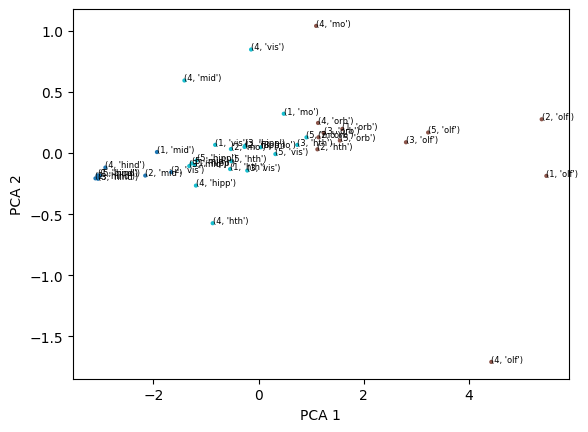

In [47]:
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)
#scatter plot
plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10',s=4)
for i, label in enumerate(nw_lbl):
    plt.text(clu_tf_pca[i,0], clu_tf_pca[i,1], label, fontsize=6)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

Supplementary 4.5

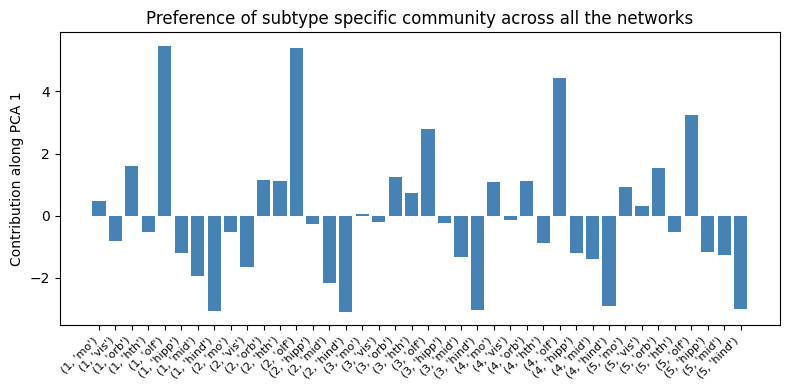

In [52]:
# Extract PCA1 coordinates
pca1_scores = clu_tf_pca[:, 0]

# Plot without sorting
fig, axpca = plt.subplots(figsize=(8,4))
axpca.bar(range(len(pca1_scores)), pca1_scores, color='steelblue')
axpca.set_xticks(range(len(nw_lbl)))
axpca.set_xticklabels(nw_lbl, rotation=45, ha='right', fontsize=8)
axpca.set_ylabel("Contribution along PCA 1")
axpca.set_title("Preference of subtype specific community across all the networks")

plt.tight_layout()
plt.show()


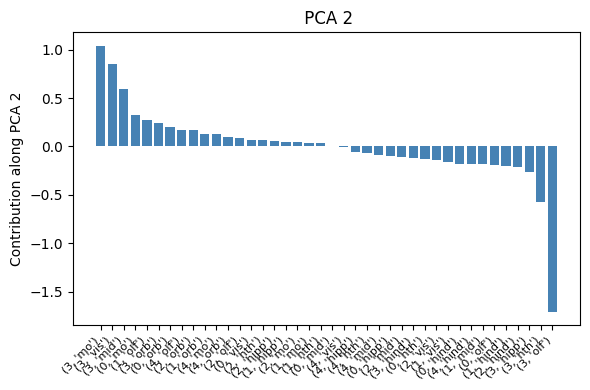

In [19]:
pca1_scores = clu_tf_pca[:, 1]

# Sort in descending order
sorted_idx = np.argsort(pca1_scores)[::-1]
sorted_labels = [nw_lbl[i] for i in sorted_idx]
sorted_scores = pca1_scores[sorted_idx]

# Plot
fig, axpca = plt.subplots(figsize=(6,4))
axpca.bar(range(len(sorted_scores)), sorted_scores, color='steelblue')
axpca.set_xticks(range(len(sorted_labels)))
axpca.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
axpca.set_ylabel("Contribution along PCA 2")
axpca.set_title(" PCA 2")

plt.tight_layout()
plt.show()

Fig 4C analysis - We want to see which network influence more which cluster subtype  
Supplementary Figures

Text(0, 0.5, 'PCA 2')

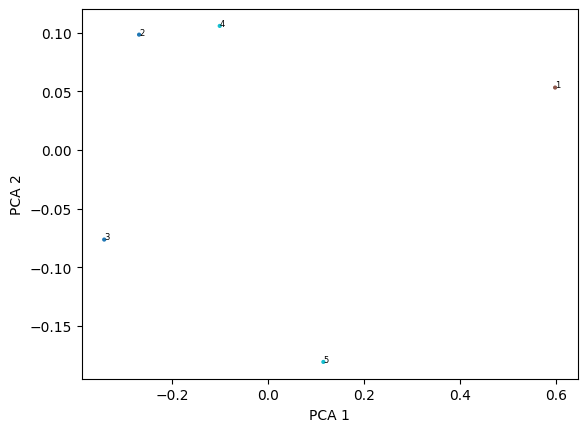

In [30]:
data_b=reader.data_read_bz2('results/figures/fig4b_data.pkl')
# do PCA
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(data_b.values)
clu_tf_pca=reducer_pca.transform(data_b.values)
# cluster label
nw_lbl = [1,2,3,4,5]
# not needed but doing
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)
#scatter plot
plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10',s=4)
for i, label in enumerate(nw_lbl):
    plt.text(clu_tf_pca[i,0], clu_tf_pca[i,1], label, fontsize=6)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

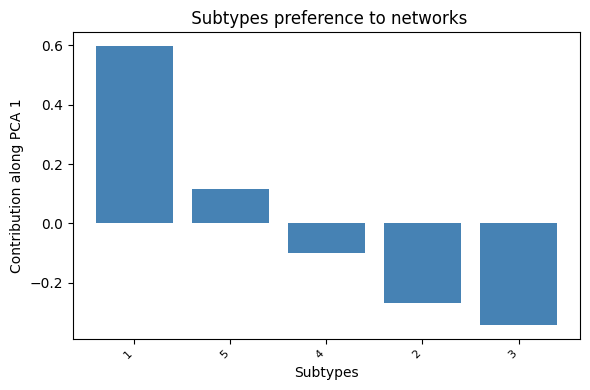

In [35]:
# Extract PCA1 coordinates
pca1_scores = clu_tf_pca[:, 0]
# Sort in descending order
sorted_idx = np.argsort(pca1_scores)[::-1]
sorted_labels = [nw_lbl[i] for i in sorted_idx]
sorted_scores = pca1_scores[sorted_idx]
# Plot
fig, axpca = plt.subplots(figsize=(6,4))
axpca.bar(range(len(sorted_scores)), sorted_scores, color='steelblue')
axpca.set_xticks(range(len(sorted_labels)))
axpca.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
axpca.set_ylabel("Contribution along PCA 1")
axpca.set_title(" Subtypes preference to networks")
axpca.set_xlabel("Subtypes")
plt.tight_layout()
plt.show()

# Figure 5

Use notebook 'Analyse Cluster Backtrack.ipynb'  
Data:  
5A: 'results/figures/fig5a_data.pkl'  
5B: 'results/figures/fig5b_data.pkl'  
5C: 'results/figures/fig5c_data.pkl'  
5BC1::'results/figures/fig5bc1_data.pkl'  
use notebook: 'Analyse Calculate Final Params.ipynb'  
5E: 'results/figures/fig5e_data.pkl'  
use notebook: 'Analyse Cluster Backtrack.ipynb'  
5F: 'results/figures/fig5f_data.pkl'  
use notebook: 'Analyse Calculate Final Params.ipynb'  
5H:'results/figures/fig5h_data.pkl'  
use notebook: 'Analyse Cluster Backtrack.ipynb'  
5I:'results/figures/fig5i_data.pkl'   NOTE: this is late slope data of Full and Part FPT , use data from 5J
use notebook: 'Analyse fit fpt st error'  
5J:'results/figures/fig5j_data.pkl'  

Defining piecewise linear fit function for FPT and ST  
(reference notebook: 'Analyse Calculate Final Params.ipynb')

In [44]:
def fit_st_fpt(data):
    intervals = data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    x = intervals
    y = log_ccdf
    # Fit piecewise linear model with 2 segments
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)
    return {'x':x,'y':y,'y_hat':y_hat}

Shapiro-Wilk Test p-value: 3.439e-01
 FIG 5E - T-statistic: 2.429, p-value: 3.178e-02


Text(-0.45, 1.15, 'J')

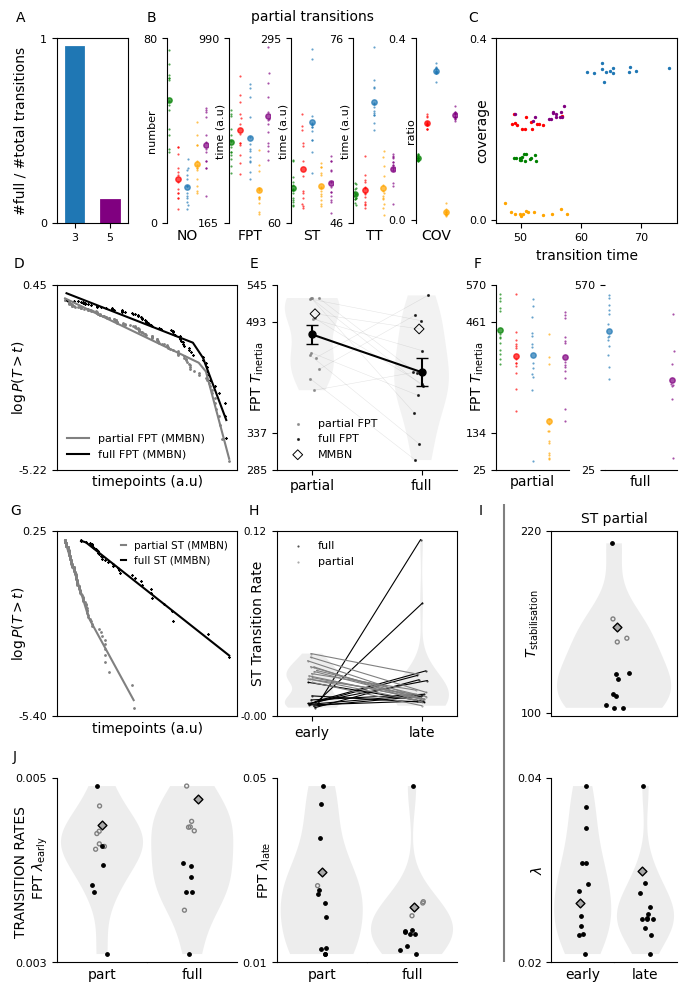

In [60]:

fig=plt.figure(figsize=(8,12))
gs=gridspec.GridSpec(23,12,wspace=2.5,hspace=1) #10 rows, 14 columns

#5A
ax1=fig.add_subplot(gs[0:5,0:2])
colors=['C0','purple']
data_a=reader.data_read_bz2('results/figures/fig5a_data.pkl')
data_a.index=[1,2,3,4,5]
data_a=data_a.drop([1,2,4])
dt=data_a['fn']
dt.columns=[3,5]
dt.plot(kind='bar',color=colors,ax=ax1,fontsize=8,edgecolor=colors,linewidth=2,rot=0)
ymin, ymax = ax1.get_ylim()
ax1.set_yticks([ymin, ymax])
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax1.tick_params(axis='y', labelsize=8)
ax1.set_xticklabels([3,5],fontsize=8)
ax1.set_ylabel('#full / #total transitions',fontsize=10,labelpad=9)


#5B
colors=["green","red","C0","orange","purple"]
data_5b=reader.data_read_pkl('results/figures/fig5b_data.pkl')
# make 5 plots inside this
sub_gs=gs[0:5,2:8].subgridspec(1,5,wspace=0.5)
# to read clusters
cl=[0,1,2,3,4]
# number of transitions
ax2a=fig.add_subplot(sub_gs[0])
ax2a.set_xticks([])
# count number of transitions by counting number of transition time
data_5b1=reader.data_read_pkl('results/figures/fig5bc1_data.pkl')['5b1']
# calculate mean for every subtype
mean_no={}
for k,v in data_5b1.items():
	mean_no[k]=np.mean(v)
#scatter plot
for i,(key,values) in enumerate(data_5b1.items()):
    jitter_x = np.random.normal(loc=i+0.04, scale=0.01, size=len(values))
    ax2a.scatter(jitter_x, values,color=colors[i], s=0.3, alpha=0.7, label=key)
    # plot mean
    mean_val=mean_no[key]
    ax2a.scatter(i+0.04,mean_val,color=colors[i], s=15, alpha=0.7, label=key)
ax2a.set_xlabel('NO',fontsize=10)
ax2a.set_ylabel('number',fontsize=8,labelpad=-10)
ymin, ymax = ax2a.get_ylim()
ax2a.set_yticks([0, 80])
ax2a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2a.tick_params(axis='y', labelsize=8)

#fpt
ax2b=fig.add_subplot(sub_gs[1])
ax2b.set_xticks([])
ymin, ymax = ax2b.get_ylim()
ax2b.set_yticks([ymin, ymax])
ax2b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2b.tick_params(axis='y', labelsize=8)
all_fpt=[]
colors=['green','red','C0','orange','purple']
for i in cl:
    all_fpt.append(data_5b[i]['fpt'])
for i, cluster_vals in enumerate(all_fpt):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2b.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
    mean = np.mean(cluster_vals)
    ax2b.scatter(i,mean,color=colors[i], s=15, alpha=0.7, label=key)
ax2b.set_xlabel('FPT', fontsize=10)
ax2b.set_ylabel('time (a.u)',fontsize=8,labelpad=-20)
ymin, ymax = ax2b.get_ylim()
ax2b.set_yticks([165, 990])
ax2b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2b.tick_params(axis='y', labelsize=8)

#st
ax2c=fig.add_subplot(sub_gs[2])
ax2c.set_xticks([])
all_st=[]
for i in cl:
    all_st.append(data_5b[i]['st'])
for i, cluster_vals in enumerate(all_st):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2c.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
    mean = np.mean(cluster_vals)
    ax2c.scatter(i,mean,color=colors[i], s=15, alpha=0.7, label=key)
ax2c.set_xlabel('ST', fontsize=10)
ax2c.set_ylabel('time (a.u)',fontsize=8,labelpad=-20)
ymin, ymax = ax2c.get_ylim()
ax2c.set_yticks([60, 295])
ax2c.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2c.tick_params(axis='y', labelsize=8)
ax2c.set_title('partial transitions',fontsize=10,y=1.05)

#tt
ax2e=fig.add_subplot(sub_gs[3])
ax2e.set_xticks([])
ymin, ymax = ax2e.get_ylim()
ax2e.set_yticks([ymin, ymax])
ax2e.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2e.tick_params(axis='y', labelsize=8)
all_tt=[]
for i in cl:
    all_tt.append(data_5b[i]['tt'])
for i, cluster_vals in enumerate(all_tt):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2e.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
    mean = np.mean(cluster_vals)
    ax2e.scatter(i,mean,color=colors[i], s=15, alpha=0.7, label=key)
ax2e.set_xlabel('TT', fontsize=10)
ax2e.set_ylabel('time (a.u)',fontsize=8,labelpad=-15)
ymin, ymax = ax2e.get_ylim()
ax2e.set_yticks([ymin, ymax])
ax2e.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2e.tick_params(axis='y', labelsize=8)


#cov
ax2d=fig.add_subplot(sub_gs[4])
ax2d.set_xticks([])
ymin, ymax = ax2d.get_ylim()
ax2d.set_yticks([ymin, ymax])
ax2d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2d.tick_params(axis='y', labelsize=8)
all_cov=[]
for i in cl:
    all_cov.append(data_5b[i]['cov'])
for i, cluster_vals in enumerate(all_cov):
    jitter_x = np.random.normal(loc=i+0.1, scale=0.01, size=len(cluster_vals))
    ax2d.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
    mean = np.mean(cluster_vals)
    ax2d.scatter(i+0.1,mean,color=colors[i], s=15, alpha=0.7, label=key)
ax2d.set_xlabel('COV', fontsize=10)
ax2d.set_ylabel('ratio',fontsize=8,labelpad=-20)
ymin, ymax = ax2d.get_ylim()
ax2d.set_yticks([0, 0.4])
ax2d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax2d.tick_params(axis='y', labelsize=8)

# hide spines
for ax in [ax2a,ax2b,ax2c,ax2d,ax2e]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)


#5C
ax3=fig.add_subplot(gs[0:5,8:12])
# use data_5b
all_cov=[]
all_tt=[]
cl=[0,1,2,3,4]
data_5b=reader.data_read_pkl('results/figures/fig5b_data.pkl')
for i in cl:
    all_cov.append(data_5b[i]['cov'])
for i in cl:
    all_tt.append(data_5b[i]['tt'])

for i, (cluster_vals,cl_cov) in enumerate(zip(all_tt,all_cov)):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax3.scatter( cluster_vals,cl_cov, color=colors[i], s=2, alpha=1)

ymin,ymax=ax3.get_ylim()
ax3.set_yticks([0,ymax])
ax3.set_xlabel('transition time', fontsize=10)
ax3.set_ylabel('coverage', fontsize=10,labelpad=-15)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax3.set_yticks([0, 0.4])
ax3.tick_params(axis='y', labelsize=8)
ax3.tick_params(axis='x', labelsize=8)


#5D
# fpt fit plot for both partial and full FN transitions
ax4=fig.add_subplot(gs[6:11,0:4])
ax4.set_xticks([])
data_5d=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
data_pfn=data_5d[1]['fp_t']
data_ffn=data_5d[2]['fp_t']
data_pfn=[x for x in data_pfn if 20<x<600]
data_ffn=[x for x in data_ffn if 20<x<600]
# doing for partial transitions
params_pfn=fit_st_fpt(data_pfn)
ax4.scatter(params_pfn['x'],params_pfn['y'], s=1,c='gray')
ax4.plot(params_pfn['x'],params_pfn['y_hat'],'gray',label='partial FPT (MMBN)')
# doing for full transitions
params_ffn=fit_st_fpt(data_ffn)
ax4.scatter(params_ffn['x'],params_ffn['y'],s=1,c='k',marker='x')
ax4.plot(params_ffn['x'],params_ffn['y_hat'],'k',label='full FPT (MMBN)')
ax4.legend(fontsize=8,frameon=False)
ax4.set_xlabel('timepoints (a.u)',fontsize=10)
ax4.set_ylabel(r'$\log P(T>t)$',fontsize=10,labelpad=-7)
ymin, ymax = ax4.get_ylim()
ax4.set_yticks([ymin, ymax])
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax4.tick_params(axis='y', labelsize=8)


#5E
ax5 = fig.add_subplot(gs[6:11, 4:8])
data_5e = reader.data_read_pkl('results/figures/fig5j_data.pkl')
dict_part = data_5e['fpt_part']['bp']
dict_full = data_5e['fpt_full']['bp']
values1 = list(dict_part.values())
values2 = list(dict_full.values())
labels = list(dict_part.keys())  # Assuming order matches between part and full

# Check normality
differences = np.array(values1) - np.array(values2)
shapiro_stat, shapiro_p = scipy.stats.shapiro(differences)
print(f"Shapiro-Wilk Test p-value: {shapiro_p:.3e}")

# Plot Violin Plots 
vp = ax5.violinplot([values1, values2], positions=[0, 1], showmeans=False, showmedians=False, showextrema=False)
# Style the violins
colors = ['#e6e6e6', '#e6e6e6'] 
for patch, color in zip(vp['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

# enerate Jitter & Separate 'fn' from Regular Data
np.random.seed(42) # For reproducible clean-looking jitter
jitter_x1 = np.random.normal(loc=0, scale=0.04, size=len(values1))
jitter_x2 = np.random.normal(loc=1, scale=0.04, size=len(values2))
reg_x1, reg_y1 = [], []
reg_x2, reg_y2 = [], []
fn_x1, fn_y1 = None, None
fn_x2, fn_y2 = None, None

for i, label in enumerate(labels):
    if label == 'fn':
        fn_x1, fn_y1 = jitter_x1[i], values1[i]
        fn_x2, fn_y2 = jitter_x2[i], values2[i]
    else:
        reg_x1.append(jitter_x1[i])
        reg_y1.append(values1[i])
        reg_x2.append(jitter_x2[i])
        reg_y2.append(values2[i])

# Plot Pairwise Connection Lines
# Keeps lines for all networks (including 'fn') in the background
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax5.plot([x1, x2], [y1, y2], color='gray', alpha=0.2, linewidth=0.4, zorder=1)

# Overlay Scatter Points
# Standard networks as regular small circular points
ax5.scatter(reg_x1, reg_y1, color='gray', s=1.5, alpha=0.7, label='partial FPT', zorder=2)
ax5.scatter(reg_x2, reg_y2, color='k', s=1.5, alpha=0.7, label='full FPT', zorder=2)

# Highlighting the 'fn' entry explicitly as a red-bordered diamond marker
if fn_x1 is not None:
    ax5.scatter(fn_x1, fn_y1, color='none', marker='D', s=25, edgecolor='black', linewidth=0.7, label='MMBN', zorder=3)
    ax5.scatter(fn_x2, fn_y2, color='none', marker='D', s=25, edgecolor='black', linewidth=0.7, zorder=3)

ax5.legend(frameon=False, fontsize=8)

# Paired T-test
t_stat, p_val = scipy.stats.ttest_rel(values1, values2)
print(f" FIG 5E - T-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")

# Means with Error Bars (Overlayed on the very top)
mean1, mean2 = np.mean(values1), np.mean(values2)
sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)

# Line connecting the two means
ax5.plot([0, 1], [mean1, mean2], color='black', linewidth=1.5, zorder=4)

# Means markers with standard error of the mean caps
ax5.errorbar(0, mean1, yerr=sem1, fmt='o', color='black', markersize=5, capsize=4, zorder=5)
ax5.errorbar(1, mean2, yerr=sem2, fmt='o', color='black', markersize=5, capsize=4, zorder=5)

# Custom Labeling and Axis Limits
ax5.set_xticks([0, 1])
ax5.set_xticklabels(['partial', 'full'], fontsize=10)
ax5.set_ylabel('FPT $T_{\mathrm{inertia}}$', fontsize=10, labelpad=-15)

# Ticks configuration
ymin = 285
ymax = 545
offset = (ymax - ymin) * 0.20
ytick_lower_inner = ymin + offset
ytick_upper_inner = ymax - offset

ax5.set_ylim(ymin, ymax)
ax5.set_yticks([ymin, ytick_lower_inner, ytick_upper_inner, ymax])
ax5.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax5.tick_params(axis='y', labelsize=8)

# Remove top and right spines
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

#5F
# FPT clusterwise T inertia
sub_gs=gs[6:11,8:12].subgridspec(1,2,wspace=0.5)
#partial
ax6a=fig.add_subplot(sub_gs[0])
ax6a.set_xticks([])
data_6a=reader.data_read_pkl('results/figures/fig5f_data.pkl')['part_fpt_tin']
colors=["green","red","C0","orange", "purple"]
for i,(key,values) in enumerate(data_6a.items()):
    jitter_x = np.random.normal(loc=i+0.04, scale=0.01, size=len(values))
    ax6a.scatter(jitter_x, values,color=colors[i], s=0.3, alpha=0.7, label=key)
    # plot mean
    mean_val=np.mean(values)
    ax6a.scatter(i+0.04,mean_val,color=colors[i], s=15, alpha=0.7, label=key)
ax6a.set_xlabel('partial', fontsize=10)
ax6a.set_ylabel('FPT $T_{\mathrm{inertia}}$', fontsize=10,labelpad=-15)
ymin, ymax = ax6a.get_ylim()
ax6a.set_yticks([25, 570])
ymin=25
ymax=570
offset = (ymax - ymin) * 0.20

ytick_lower_inner = ymin + offset
ytick_upper_inner = ymax - offset

# Apply all 4 precise ticks to the axis
ax6a.set_yticks([ymin, ytick_lower_inner, ytick_upper_inner, ymax])
ax6a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax6a.tick_params(axis='y', labelsize=8)


#full
ax6b=fig.add_subplot(sub_gs[1])
data_6b=reader.data_read_pkl('results/figures/fig5f_data.pkl')['full_fpt_tin']
ax6b.set_xticks([])
ax6b.spines['left'].set_visible(False)
colors=['C0','purple']
for i,(key,values) in enumerate(data_6b.items()):
    jitter_x = np.random.normal(loc=i-0.5, scale=0.01, size=len(values))
    ax6b.scatter(jitter_x, values,color=colors[i], s=0.3, alpha=0.7, label=key)
    # plot mean
    mean_val=np.mean(values)
    ax6b.scatter(i-0.5,mean_val,color=colors[i], s=15, alpha=0.7, label=key)
ax6b.set_xlabel('full',fontsize=10)
# hide spines
for ax in [ax6a,ax6b]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax6b.set_yticks([25, 570])
ax6b.tick_params(axis='y', labelsize=8)


#5G
#st
ax7=fig.add_subplot(gs[12:17,0:4])
ax7.set_xticks([])
data_5f=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
data_pfn=data_5d[1]['s_t']
data_ffn=data_5d[2]['s_t']
data_pfn=[x for x in data_pfn if 25<x<800]
data_ffn=[x for x in data_ffn if 25<x<800]
params_pfn=fit_st_fpt(data_pfn)
ax7.scatter(params_pfn['x'],params_pfn['y'], s=1,c='gray')
ax7.plot(params_pfn['x'],params_pfn['y_hat'],'gray',label='partial ST (MMBN)')
params_ffn=fit_st_fpt(data_ffn)
ax7.scatter(params_ffn['x'],params_ffn['y'],s=1,c='k',marker='x')
ax7.plot(params_ffn['x'],params_ffn['y_hat'],'k',label='full ST (MMBN)')
ax7.legend(fontsize=7.5, frameon=False, loc="upper right",handlelength=0.5)
ax7.set_xlabel('timepoints (a.u)',fontsize=10)
ax7.set_ylabel(r'$\log P(T > t)$', fontsize=10, labelpad=-7)
ymin, ymax = ax7.get_ylim()
ax7.set_yticks([ymin, ymax])
ax7.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax7.tick_params(axis='y', labelsize=8)


#5H
# ST early and late
ax8 = fig.add_subplot(gs[12:17, 4:8])
ax8.set_xticks([])
data_5h = reader.data_read_pkl('results/figures/fig5h_data.pkl')
values_full_early = np.abs(data_5h['full']['early'][1:])
values_full_late = np.abs(data_5h['full']['late'][1:])
values_part_early = np.abs(data_5h['part']['early'])
values_part_late = np.abs(data_5h['part']['late'])

# Combine partial and full data for a comprehensive background distribution shape
combined_early = np.concatenate([values_full_early, values_part_early])
combined_late = np.concatenate([values_full_late, values_part_late])
vp = ax8.violinplot([combined_early, combined_late], positions=[0, 1], 
                    showmeans=False, showmedians=False, showextrema=False, widths=0.5)

# Style the violins to be light gray
for body in vp['bodies']:
    body.set_facecolor('lightgray')
    body.set_edgecolor('none')
    body.set_alpha(0.4)
    body.set_zorder(1)  

jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values_full_early)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values_full_late)))

ax8.scatter(jitter_x1, values_full_early, color='k', s=0.3, alpha=0.7, label='full', zorder=3)
ax8.scatter(jitter_x2, values_full_late, color='k', s=0.3, alpha=0.7, zorder=3)

for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values_full_early), zip(jitter_x2, values_full_late)):
    ax8.plot([x1, x2], [y1, y2], color='k', linewidth=0.8, zorder=2)

# Plot partial transition paired plot 
jitter_x1_p = list(np.random.normal(loc=0, scale=0.03, size=len(values_part_early)))
jitter_x2_p = list(np.random.normal(loc=1, scale=0.03, size=len(values_part_late)))

ax8.scatter(jitter_x1_p, values_part_early, color='gray', s=0.3, alpha=0.7, label='partial', zorder=3)
ax8.scatter(jitter_x2_p, values_part_late, color='gray', s=0.3, alpha=0.7, zorder=3)

for (x1, y1), (x2, y2) in zip(zip(jitter_x1_p, values_part_early), zip(jitter_x2_p, values_part_late)):
    ax8.plot([x1, x2], [y1, y2], color='gray', linewidth=0.8, zorder=2)

# Formatting 
ax8.legend(frameon=False, fontsize=8)
ax8.set_xticks([0, 1])
ax8.set_xticklabels(['early', 'late'], fontsize=10)
ax8.set_ylabel('ST Transition Rate', fontsize=10, labelpad=-18)

ymin, ymax = ax8.get_ylim()
ax8.set_yticks([ymin, ymax])
ax8.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax8.tick_params(axis='y', labelsize=7.5)


#5I
# draw a line to separate partial transitions
ax9=fig.add_subplot(gs[12:17,9:12])
ax9.set_xticks([])
data_5j=reader.data_read_pkl('results/figures/fig5j_data.pkl')
data_5ja=data_5j['st_part']['bp']
snw_ja=data_5j['st_part']['s_j']
all_values=list(data_5ja.values())
violin_parts=ax9.violinplot(all_values,positions=[1],showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
for k, v in data_5ja.items():
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_ja:
        # significant nw
        ax9.scatter(x_jitter,v,s=6,zorder=2,c='k')
    elif k=='fn':
        ax9.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax9.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
ax9.set_title('ST partial',fontsize=10)
ymin, ymax = ax9.get_ylim()
ax9.set_yticks([100, 220])
ax9.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax9.tick_params(axis='y', labelsize=8)
ax9.set_ylabel("$T_{\mathrm{stabilisation}}$",fontsize=10,labelpad=-15)


#5J
data_5j=reader.data_read_pkl('results/figures/fig5j_data.pkl')
# FPT early slope full
sub_gs=gs[18:23,0:4].subgridspec(1,2,wspace=0)
ax10b=fig.add_subplot(sub_gs[0])
ax10b.set_xticks([])
data_5jb=data_5j['fpt_part']['slp1']
# list of significant nw
snw_jb=data_5j['fpt_part']['s_nw']
# violin plot for all values
all_values=[abs(x) for x in data_5jb.values()]
violin_parts=ax10b.violinplot(all_values,positions=[1],showmeans=False,
                              showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
    
for k,v in data_5jb.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_jb:
        # significant nw
        ax10b.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10b.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10b.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10b.set_xlabel('part',fontsize=10)
ymin, ymax = ax10b.get_ylim()
ax10b.set_yticks([ymin, ymax])
ax10b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax10b.tick_params(axis='y', labelsize=8)
ax10b.set_ylabel("TRANSITION RATES \n FPT $\lambda_{\mathrm{early}}$", fontsize=10, labelpad=-25, y=0.5)




#FPT early slope part
ax10c=fig.add_subplot(sub_gs[1])
ax10c.set_xticks([])
data_5jc=data_5j['fpt_full']['slp1']
snw_jc=data_5j['fpt_full']['s_nw']
all_values=[abs(x) for x in data_5jc.values()]
violin_parts=ax10c.violinplot(all_values,positions=[1],showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
for k,v in data_5jc.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_jc:
        # significant nw
        ax10c.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10c.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10c.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10c.set_xlabel('full',fontsize=10)
ymin, ymax = ax10c.get_ylim()
ax10c.set_yticks([ymin, ymax])
ax10c.set_yticks([])
ax10c.spines['left'].set_visible(False)


# FPT late slope full
sub_gs=gs[18:23,4:8].subgridspec(1,2,wspace=0)
ax10d=fig.add_subplot(sub_gs[0])
ax10d.set_xticks([])
data_5i = reader.data_read_pkl('results/figures/fig5i_data.pkl')
data_5id=data_5i['fpt_part']['slp2']
snw_id=data_5i['fpt_part']['s_nw']
all_values=[abs(x) for x in data_5id.values()]
violin_parts=ax10d.violinplot(all_values,positions=[1],showmeans=False,
                              showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
    
for k,v in data_5id.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_id:
        # significant nw
        ax10d.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10d.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10d.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10d.set_xlabel('part',fontsize=10)
ymin, ymax = ax10d.get_ylim()
ax10d.set_yticks([ymin,ymax])
ax10d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax10d.tick_params(axis='y', labelsize=8)
ax10d.set_ylabel("FPT $\lambda_{\mathrm{late}}$",fontsize=10,labelpad=-22)

# FPT late slope part
ax10e=fig.add_subplot(sub_gs[1])
ax10e.set_xticks([])
data_5i = reader.data_read_pkl('results/figures/fig5i_data.pkl')
data_5ie=data_5i['fpt_full']['slp2']
# list of significant nw
snw_ie=data_5i['fpt_full']['s_nw']
# violin plot for all values
all_values=[abs(x) for x in data_5ie.values()]
violin_parts=ax10e.violinplot(all_values,positions=[1],showmeans=False,
                              showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
    
for k,v in data_5ie.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_ie:
        # significant nw
        ax10e.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10e.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10e.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10e.set_xlabel('full',fontsize=10)
ax10e.set_yticks([ymin,ymax])
ax10e.set_yticks([])
ax10e.spines['left'].set_visible(False)


#ST early slope part
sub_gs=gs[18:23,9:12].subgridspec(1,2,wspace=0)
ax10f=fig.add_subplot(sub_gs[0])
ax10f.set_xticks([])
data_5jf=data_5j['st_part']['slp1']
# list of significant nw
snw_jf=data_5j['st_part']['s_nw']
# violin plot for all values
all_values=[abs(x) for x in data_5jf.values()]
violin_parts=ax10f.violinplot(all_values,positions=[1],showmeans=False,
                              showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
    
for k,v in data_5jf.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_jf:
        # significant nw
        ax10f.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10f.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10f.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10f.set_xlabel('early',fontsize=10)
ymin, ymax = ax10f.get_ylim()
ax10f.set_yticks([ymin, ymax])
ax10f.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax10f.tick_params(axis='y', labelsize=8)
ax10f.set_ylabel("$\lambda}$",fontsize=10,labelpad=-20)
ax10f.tick_params(axis='y', labelsize=8)


# ST late slope part
ax10g=fig.add_subplot(sub_gs[1])
ax10g.set_xticks([])
data_5ig=data_5i['st_part']['slp2']
# list of significant nw
snw_ig=data_5i['st_part']['s_nw']
# violin plot for all values
all_values=[abs(x) for x in data_5ig.values()]
violin_parts=ax10g.violinplot(all_values,positions=[1],showmeans=False,
                              showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgray')
    pc.set_alpha(0.4)
    pc.set_zorder(1)
    
for k,v in data_5ig.items():
    v=abs(v)
    x_jitter = np.random.normal(loc=1.0, scale=0.03)
    if k in snw_ig:
        # significant nw
        ax10g.scatter(x_jitter,v,s=6,zorder=2,c='k')
        
    elif k=='fn':
        ax10g.scatter(x_jitter,[v],c='darkgray',s=20,zorder=2,marker='D',edgecolors='k')
    else:
        ax10g.scatter(x_jitter,v,s=8,zorder=2,edgecolors='gray',facecolors='none', marker='o')
        
ax10g.set_xlabel('late',fontsize=10)
ymin, ymax = ax10g.get_ylim()
ax10g.set_yticks([ymin, ymax])
ax10g.set_yticks([])
ax10g.spines['left'].set_visible(False)

# draw a line to separate partial ST
ax11 = fig.add_subplot(gs[11:23, 8:9])
ax11.set_xticks([])
ax11.set_yticks([])
ax11.spines['bottom'].set_visible(False)
ax11.spines['left'].set_visible(False)
ax11.set_ylim(0, 1)

ax11.vlines(x=-8, ymin=0, ymax=0.97, color='gray', linestyle='-')
ax11.set_yticks([])
for ax in [ax10b,ax10c,ax10d,ax10e,ax10f,ax10g,ax11]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



#panel A
ax1.text(-0.45, 1.15, "A", transform=ax1.transAxes,
         fontsize=10, va="top", ha="right")
# Panel B
ax2a.text(-0.25, 1.15, "B", transform=ax2a.transAxes,
         fontsize=10, va="top", ha="right")
# Panel C
ax3.text(-0.1, 1.15, "C", transform=ax3.transAxes,
         fontsize=10, va="top", ha="right")
#panel D
ax4.text(-0.18, 1.15, "D", transform=ax4.transAxes,
         fontsize=10, va="top", ha="right")
#panel E
ax5.text(-0.1, 1.15, "E", transform=ax5.transAxes,
         fontsize=10, va="top", ha="right")
# panel F
ax6a.text(-0.2, 1.15, "F", transform=ax6a.transAxes,
         fontsize=10, va="top", ha="right")
#panel G
ax7.text(-0.2, 1.15, "G", transform=ax7.transAxes,
         fontsize=10, va="top", ha="right")
#panel H
ax8.text(-0.1, 1.15, "H", transform=ax8.transAxes,
         fontsize=10, va="top", ha="right")
#panel I
ax11.text(-0.9, 0.97, "I", transform=ax11.transAxes,
         fontsize=10, va="top", ha="right")
#panel J
ax10b.text(-0.45, 1.15, "J", transform=ax10b.transAxes,
         fontsize=10, va="top", ha="right")

Pairwise for 5b

In [61]:

# Remapping internal cluster keys 0-4 to match your display IDs 1-5
cl_mapping = {0: 1, 1: 2, 2: 3, 3: 4, 4: 5}
metric = 'st'  # Swap to 'tt' to run the table for Transition Time
# Read your pkl file
data_5b = reader.data_read_pkl('results/figures/fig5b_data.pkl')
pairs = []
raw_p_values = []

# Loop over combinations to set up pairs (e.g., C1 vs C2, C1 vs C3...)
keys = list(cl_mapping.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        c1_idx, c2_idx = keys[i], keys[j]
        c1_display, c2_display = cl_mapping[c1_idx], cl_mapping[c2_idx]
        
        # Pull arrays
        group1 = data_5b[c1_idx][metric]
        group2 = data_5b[c2_idx][metric]
        
        # Execute Mann-Whitney U test
        stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        
        pairs.append((f"Subtype {c1_display}", f"Subtype {c2_display}"))
        raw_p_values.append(p_val)

# -Multiple Comparisons Adjustments (Holm-Bonferroni) 
# This scales up p-values dynamically to control the family-wise error rate
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Assemble the Final Significance DataFrame ---
table_data = []
for (c1, c2), raw_p, corr_p in zip(pairs, raw_p_values, corrected_p_values):
    # Map p-values to standard APA star notation
    if corr_p < 0.001:
        stars = "<0.001"
    elif corr_p < 0.01:
        stars = "<0.01"
    elif corr_p < 0.05:
        stars = "<0.05"
    else:
        stars = "ns"  # Not significant
        
    table_data.append({
        "Comparison": f"{c1} vs {c2}",
        "Raw p-value": f"{raw_p:.2e}",
        "Corrected p-value": f"{corr_p:.2e}" if corr_p >= 0.001 else "< 0.001",
        "Significance": stars
    })

df_significance = pd.DataFrame(table_data)

# --- 5. Display the Table ---
print(f"\n--- Pairwise Significance Matrix for {metric.upper()} ---")
print(df_significance.to_string(index=False))


--- Pairwise Significance Matrix for ST ---
            Comparison Raw p-value Corrected p-value Significance
Subtype 1 vs Subtype 2    2.93e-01          1.00e+00           ns
Subtype 1 vs Subtype 3    2.61e-05           < 0.001       <0.001
Subtype 1 vs Subtype 4    7.20e-01          1.00e+00           ns
Subtype 1 vs Subtype 5    5.38e-01          1.00e+00           ns
Subtype 2 vs Subtype 3    4.08e-03          2.86e-02        <0.05
Subtype 2 vs Subtype 4    4.12e-01          1.00e+00           ns
Subtype 2 vs Subtype 5    4.42e-01          1.00e+00           ns
Subtype 3 vs Subtype 4    4.09e-05           < 0.001       <0.001
Subtype 3 vs Subtype 5    5.09e-05           < 0.001       <0.001
Subtype 4 vs Subtype 5    7.00e-01          1.00e+00           ns


Pairwise for 5F

In [63]:

# Structure: dict_keys(['part_fpt_tin', 'full_fpt_tin'])
data_5f = reader.data_read_pkl('results/figures/fig5f_data.pkl')

def generate_pairwise_table(dataset_dict, cluster_mappings, title):
    """
    Computes pairwise Mann-Whitney U tests with Holm correction 
    for a given dataset dictionary and cluster key-to-display mappings.
    """
    pairs = []
    raw_p_values = []
    keys = list(dataset_dict.keys())
    if len(keys) < 2:
        print(f"\n--- {title} ---")
        print("Not enough clusters for pairwise comparison.")
        return

    # Gather pairs and run raw Mann-Whitney U tests
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            k1, k2 = keys[i], keys[j]
            
            # Map to your display IDs using the provided mapping dictionary
            c1_display = cluster_mappings.get(k1, f"subtype {k1}")
            c2_display = cluster_mappings.get(k2, f"subtype {k2}")
            
            group1 = dataset_dict[k1]
            group2 = dataset_dict[k2]
            
            # Run two-sided test
            stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
            
            pairs.append((c1_display, c2_display))
            raw_p_values.append(p_val)

    # Apply Multiple Comparisons Correction (Holm-Bonferroni)
    reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

    # Format the results into a table frame
    table_data = []
    for (c1, c2), raw_p, corr_p in zip(pairs, raw_p_values, corrected_p_values):
        if corr_p < 0.001:
            stars = "<0.001"
        elif corr_p < 0.01:
            stars = "<0.01"
        elif corr_p < 0.05:
            stars = "<0.05"
        else:
            stars = "ns"
            
        table_data.append({
            "Comparison": f"{c1} vs {c2}",
            "Raw p-value": f"{raw_p:.2e}",
            "Corrected p-value": f"{corr_p:.2e}" if corr_p >= 0.001 else "< 0.001",
            "Significance": stars
        })

    df = pd.DataFrame(table_data)
    print(f"\n--- Pairwise Significance: {title} ---")
    print(df.to_string(index=False))



# Mapping 0-4 keys to display labels 1-5
part_mappings = {0: "Cluster 1", 1: "Cluster 2", 2: "Cluster 3", 3: "Cluster 4", 4: "Cluster 5"}
generate_pairwise_table(data_5f['part_fpt_tin'], part_mappings, "Partial FPT Time Inertia")



# colors=['C0','purple'] -> maps to Cluster 3 and Cluster 5
# The dictionary keys for full are 0 and 1 internally
full_mappings = {0: "Cluster 3", 1: "Cluster 5"}
generate_pairwise_table(data_5f['full_fpt_tin'], full_mappings, "Full FPT Time Inertia")


--- Pairwise Significance: Partial FPT Time Inertia ---
              Comparison Raw p-value Corrected p-value Significance
subtype c0 vs subtype c1    2.74e-02          1.64e-01           ns
subtype c0 vs subtype c2    1.12e-01          4.48e-01           ns
subtype c0 vs subtype c3    1.33e-04          1.33e-03        <0.01
subtype c0 vs subtype c4    2.74e-02          1.64e-01           ns
subtype c1 vs subtype c2    8.58e-01          1.00e+00           ns
subtype c1 vs subtype c3    1.48e-03          1.33e-02        <0.05
subtype c1 vs subtype c4    9.59e-01          1.00e+00           ns
subtype c2 vs subtype c3    5.62e-03          3.93e-02        <0.05
subtype c2 vs subtype c4    8.37e-01          1.00e+00           ns
subtype c3 vs subtype c4    2.09e-03          1.67e-02        <0.05

--- Pairwise Significance: Full FPT Time Inertia ---
              Comparison Raw p-value Corrected p-value Significance
subtype c2 vs subtype c4    4.54e-03          4.54e-03        <0.01


pairwise of 3 and 5 both partial and full

In [64]:
import numpy as np
import pandas as pd
from scipy import stats


# data_6a - dict_keys(['c0', 'c1', 'c2', 'c3', 'c4'])  <- Partial Map
# data_6b - dict_keys(['c2', 'c4'])                  <- Full Map

# Define the 4 specific cross-condition pairwise combinations
comparisons = [
    {
        "dict1": data_6a, "dict2": data_6b, "k1": 'c2', "k2": 'c2', 
        "label1": "Subtype 3 (Partial)", "label2": "Subtype 3 (Full)"
    },
    {
        "dict1": data_6a, "dict2": data_6b, "k1": 'c2', "k2": 'c4', 
        "label1": "Subtype 3 (Partial)", "label2": "Subtype 5 (Full)"
    },
    {
        "dict1": data_6a, "dict2": data_6b, "k1": 'c4', "k2": 'c2', 
        "label1": "Subtype 5 (Partial)", "label2": "Subtype 3 (Full)"
    },
    {
        "dict1": data_6a, "dict2": data_6b, "k1": 'c4', "k2": 'c4', 
        "label1": "Subtype 5 (Partial)", "label2": "Subtype 5 (Full)"
    }
]

table_data = []


for comp in comparisons:
    group1 = comp["dict1"][comp["k1"]]
    group2 = comp["dict2"][comp["k2"]]
    
    # Run two-sided Mann-Whitney U test
    stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Format the significance string
    if p_val < 0.001:
        stars = "<0.001"
    elif p_val < 0.01:
        stars = "<0.01"
    elif p_val < 0.05:
        stars = "<0.05"
    else:
        stars = "ns"
        
    # Append each result directly into your dictionary table format
    table_data.append({
        "Comparison": f"{comp['label1']} vs {comp['label2']}",
        "U-statistic": f"{stat:.2f}",
        "p-value": f"{p_val:.2e}" if p_val >= 0.001 else "< 0.001",
        "Significance": stars
    })


df = pd.DataFrame(table_data)

print("\n--- Pairwise Significance: Subtype Dynamics ---")
print(df.to_string(index=False))


--- Pairwise Significance: Subtype Dynamics ---
                             Comparison U-statistic  p-value Significance
Subtype 3 (Partial) vs Subtype 3 (Full)       54.50 1.30e-01           ns
Subtype 3 (Partial) vs Subtype 5 (Full)       74.00 1.21e-01           ns
Subtype 5 (Partial) vs Subtype 3 (Full)       46.00 5.12e-02           ns
Subtype 5 (Partial) vs Subtype 5 (Full)       71.00 1.85e-01           ns


5H test

In [65]:

values_full_early = data_5h['full']['early'][1:]
values_full_late  = data_5h['full']['late'][1:]
values_part_early = data_5h['part']['early']
values_part_late  = data_5h['part']['late']


comparisons = [
    ("Full vs Partial (EARLY)", values_full_early, values_part_early),
    ("Full vs Partial (LATE)",  values_full_late,  values_part_late),
    ("Early vs Late (FULL)",    values_full_early, values_full_late),
    ("Early vs Late (PARTIAL)", values_part_early, values_part_late)
]

raw_p_values = []
u_statistics = []

for name, group1, group2 in comparisons:
    stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    u_statistics.append(stat)
    raw_p_values.append(p_val)


reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')


table_data = []
for i, (name, _, _) in enumerate(comparisons):
    corr_p = corrected_p_values[i]
    raw_p = raw_p_values[i]
    u_stat = u_statistics[i]
    
    if corr_p < 0.001:
        stars = "***"
    elif corr_p < 0.01:
        stars = "**"
    elif corr_p < 0.05:
        stars = "*"
    else:
        stars = "ns"
        
    # Appending dictionary blocks to table_data matching your precise format
    table_data.append({
        "Comparison": name,
        "U-Statistic": f"{u_stat:.1f}",
        "Raw p-value": f"{raw_p:.2e}",
        "Corrected p-value": f"{corr_p:.2e}" if corr_p >= 0.001 else "< 0.001",
        "Significance": stars
    })

# Convert the array of dictionaries directly into a DataFrame
df = pd.DataFrame(table_data)
print("\n--- Pairwise Significance: FIG 5H ---")
print(df.to_string(index=False))
print("\nSignificance markers: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")


--- Pairwise Significance: FIG 5H ---
             Comparison U-Statistic Raw p-value Corrected p-value Significance
Full vs Partial (EARLY)       155.0    3.17e-05           < 0.001          ***
 Full vs Partial (LATE)        48.0    1.09e-01          1.09e-01           ns
   Early vs Late (FULL)       131.0    7.31e-04          1.46e-03           **
Early vs Late (PARTIAL)         5.0    5.09e-05           < 0.001          ***

Significance markers: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


# figure 6  
- Use 'df_data' from figure 3  for starting 7 rows  
- use notebook 'Analyse fit fpt st error.ipynb'  
Data at 'results/figures/fig6_data.pkl'  
Data for centrality at 'results/figures/fig6_bc.pkl'  

In [66]:
# in ascending order of betweenness centrality
network_asc = [
    "fn",
    "mob",
    "lsc",
    "orb",
    "pir",
    "bla",
    "mrn",
    "re",
    "enti",
    "peri",
    "mos",
    "lha",
    "mop",
]

# control node
# remove mop from control node as it is rich club
control_node = [251, 38, 71, 284, 149, 362]
control_name = ["mob", "lsc", "mrn"]
# remove mop as it is rich club
cn=[1,2,6]
dict_cn=dict(zip(control_name,cn))

#rich club node
rich_club_node = [214, 1, 215, 2, 249, 36, 137, 350]
rich_club_node_name = ["mop", "mos","lha"]
# removing peri as it is rich club
rc=[12,10,11]
dict_rc=dict(zip(rich_club_node_name,rc))

# important nodes
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["peri", "enti", "orb", "re", "bla", "pir"]
fi=[9,8,3,7,5,4]
dict_fi=dict(zip(imp_name,fi))

#important + rich club
dict_irc={'peri':9}

In [67]:
dict_rc

{'mop': 12, 'mos': 10, 'lha': 11}

Making data for fig 6  

In [68]:
df_s7=df_data.copy()
df_s7

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  1.000000   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  1.000000   
orb        136   94  11.661904   9.695360  53.057721  1.124891  1.000000   
pir        110   67  10.488088   8.185353  54.763636  1.241981  1.000000   
bla        107   51  10.344080   7.141428  54.188318  1.117801  1.000000   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  1.000000   
re         200   92  14.142136   9.591663  54.124500  0.763217  1.000000   
enti       151   57  12.288206   7.549834  53.687417  0.960022  1.000000   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.141772   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.443728   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.443728   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.443728   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  1.000000  ...  1.000000  351.034483  47.294445   
lsc   79.419588  1.289129  1.000000  ...  1.000000  311.785714  68.102203   
orb   82.572340  1.616342  1.000000  ...  1.000000  347.413793  32.158404   
pir   80.195522  1.615760  1.000000  ...  0.440930  399.047619  67.131559   
bla   80.609804  1.689315  1.000000  ...  1.000000  230.625000  28.823784   
mrn   78.601899  1.529340  1.000000  ...  1.000000  407.600000  58.272546   
re    77.778261  1.304602  1.000000  ...  1.000000  487.000000  70.648425   
enti  76.766667  1.499051  1.000000  ...  1.000000  399.722222  54.870038   
peri  79.453191  1.495899  0.141772  ...  0.086728  253.333333  28.349668   
mos   85.559524  2.795582  0.443728  ...  1.000000  268.125000  29.287603   
lha   78.384545  1.645938  0.443728  ...  0.160528  358.000000  83.694683   
mop   78.736111  1.935845  0.443728  ...  1.000000  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   1.000000  0.167642  0.008659  1.000000  0.546801  0.007664  1.000000  
lsc   1.000000  0.186380  0.006779  1.000000  0.570075  0.006157  1.000000  
orb   1.000000  0.147165  0.008332  0.313549  0.526395  0.008266  0.106112  
pir   0.440930  0.167115  0.009095  1.000000  0.540389  0.008939  1.000000  
bla   1.000000  0.199997  0.010300  1.000000  0.582879  0.008483  0.289324  
mrn   1.000000  0.172446  0.007612  1.000000  0.518023  0.008323  0.007235  
re    1.000000  0.189600  0.007044  1.000000  0.546913  0.007366  1.000000  
enti  1.000000  0.172499  0.007728  1.000000  0.556293  0.008835  1.000000  
peri  0.086728  0.155180  0.010715  1.000000  0.570277  0.009150  1.000000  
mos   1.000000  0.156893  0.007194  1.000000  0.558530  0.010439  1.000000  
lha   0.160528  0.172548  0.006927  1.000000  0.514550  0.009643  0.007615  
mop   1.000000  0.150628  0.007123  0.497591  0.536189  0.007992  0.617734  

[13 rows x 28 columns]

Read centrality value

In [69]:
bc=reader.data_read_pkl('results/figures/fig6_bc.pkl')
bc=list(bc)
bc

[-1.1751867976129389,
 -1.17222068267226,
 -1.1025698002281958,
 -0.9703892335862221,
 -0.7773011899514786,
 -0.16675303481588796,
 -0.040160353248531545,
 0.53241352496345,
 0.8863463038111881,
 1.1380321777660578,
 1.2920610173306268,
 1.5557280682441947]

1. Number of partial transitions  

In [71]:

# using poisson mean test  
mmbn_part = df_s7['num_trans']['part']['fn']
nepochs = 40000

# Arrays to gather raw data across the loops
network_labels = []
stat_values = []
raw_p_values = []
observed_counts = []

# Collect statistics across all parallel candidate networks ---
# Starting from index 1 to skip 'fn' baseline automatically
for nw in df_s7.index[1:]:
    current_count = df_s7['num_trans']['part'][nw]
    s, p = scipy.stats.poisson_means_test(current_count, nepochs, mmbn_part, nepochs)
    
    network_labels.append(nw)
    stat_values.append(s)
    raw_p_values.append(p)
    observed_counts.append(current_count)

# Apply Holm-Bonferroni Multiple-Testing Correction
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Separate into Significant & Insignificant Increase/Decrease Groups
r_snw = [] # significant increase
b_snw = [] # significant decrease

r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Obs Count':<10} | {'Stat (S)':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for label, count, stat, raw_p, corr_p, is_significant in zip(network_labels, observed_counts, stat_values, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = count > mmbn_part
    
    if is_significant:
        if is_increase:
            r_snw.append(label)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(label)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(label)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(label)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{label:<15} | {count:<10} | {stat:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group variable matches your exact design specifications
no_p = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Obs Count  | Stat (S)   | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 132        | -3.0794    | 2.0416e-03   | 1.8375e-02   | Sig Decrease (b_snw)
lsc             | 187        | 0.0000     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
orb             | 136        | -2.8377    | 4.5027e-03   | 3.6022e-02   | Sig Decrease (b_snw)
pir             | 110        | -4.4680    | 7.1609e-06   | 7.1609e-05   | Sig Decrease (b_snw)
bla             | 107        | -4.6657    | 2.7199e-06   | 2.9919e-05   | Sig Decrease (b_snw)
mrn             | 148        | -2.1308    | 3.3243e-02   | 1.9946e-01   | Insig Decrease (b_nw)
re              | 200        | 0.6608     | 5.0967e-01   | 1.0000e+00   | Insig Increase (r_nw)
enti            | 151        | -1.9581    | 5.0141e-02   | 2.5071e-01   | Insig Decrease (b_nw)
peri            | 79         | -6.6219    | 1.8835e-11   |

In [32]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['num_trans']['part'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: 0.12416826842041748 p-value: 0.7006247396575459


2. Number of full transitions

In [72]:
# using poisson mean test  
mmbn_full = df_s7['num_trans']['full']['fn']
nepochs = 40000

# Arrays to gather raw data across the loops
network_labels = []
stat_values = []
raw_p_values = []
observed_counts = []

# Collect statistics across all parallel candidate networks ---
# Starting from index 1 to skip 'fn' baseline automatically
for nw in df_s7.index[1:]:
    current_count = df_s7['num_trans']['full'][nw]
    s, p = scipy.stats.poisson_means_test(current_count, nepochs, mmbn_full, nepochs)
    
    network_labels.append(nw)
    stat_values.append(s)
    raw_p_values.append(p)
    observed_counts.append(current_count)

# Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease

r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Obs Count':<10} | {'Stat (S)':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for label, count, stat, raw_p, corr_p, is_significant in zip(network_labels, observed_counts, stat_values, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = count > mmbn_full
    
    if is_significant:
        if is_increase:
            r_snw.append(label)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(label)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(label)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(label)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{label:<15} | {count:<10} | {stat:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group variable matches your specifications
no_f = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Obs Count  | Stat (S)   | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 94         | -0.6412    | 5.2326e-01   | 1.0000e+00   | Insig Decrease (b_nw)
lsc             | 97         | -0.4243    | 6.7361e-01   | 1.0000e+00   | Insig Decrease (b_nw)
orb             | 94         | -0.6412    | 5.2326e-01   | 1.0000e+00   | Insig Decrease (b_nw)
pir             | 67         | -2.7611    | 5.6630e-03   | 3.9641e-02   | Sig Decrease (b_snw)
bla             | 51         | -4.1903    | 2.4345e-05   | 2.4345e-04   | Sig Decrease (b_snw)
mrn             | 79         | -1.7790    | 7.5121e-02   | 3.7560e-01   | Insig Decrease (b_nw)
re              | 92         | -0.7877    | 4.3258e-01   | 1.0000e+00   | Insig Decrease (b_nw)
enti            | 57         | -3.6366    | 2.6436e-04   | 2.1149e-03   | Sig Decrease (b_snw)
peri            | 47         | -4.5724    | 3.8381e-06   

In [35]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['num_trans']['full'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.6286743386185251 p-value: 0.028548226029793372


3. Transition time partial

In [73]:
# Baseline mean comparison value
mmbn_part = df_s7['trans_time']['part']['fn']

# Isolate the candidate networks and their raw p-values ---
# Extracting everything starting from index 1 to automatically skip the 'fn' baseline row
network_labels = list(df_s7.index[1:])
observed_means = list(df_s7['trans_time']['part'][1:])
raw_p_values = list(df_s7['trans_time']['part_mw'][1:])

# Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate across all network comparisons
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Mean Value':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for nw, mean_val, raw_p, corr_p, is_significant in zip(network_labels, observed_means, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = mean_val > mmbn_part
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {mean_val:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your layout specification
tt_p = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Mean Value | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 54.7761    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
lsc             | 55.5299    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
orb             | 53.0577    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
pir             | 54.7636    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
bla             | 54.1883    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
mrn             | 52.9966    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
re              | 54.1245    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
enti            | 53.6874    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
peri            | 50.6810    | 1.4177e-01   | 1.0000e+00   | Insig Decrease (b_nw)
mos             | 52.1038    | 4.4373e-01   | 1.0000e+00   | Insig Decrease (b_nw)
lha  

In [74]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['trans_time']['part'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.7992244075336774 p-value: 0.001814120279647202


4. Transition Time Full

In [75]:
# Baseline mean comparison value
mmbn_full = df_s7['trans_time']['full']['fn']

# -solate the candidate networks and their raw p-values 
# Extracting everything starting from index 1 to automatically skip the 'fn' baseline row
network_labels = list(df_s7.index[1:])
observed_means = list(df_s7['trans_time']['full'][1:])
raw_p_values = list(df_s7['trans_time']['full_mw'][1:])

# Apply Holm-Bonferroni Multiple-Testing Correction 
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Mean Value':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for nw, mean_val, raw_p, corr_p, is_significant in zip(network_labels, observed_means, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = mean_val > mmbn_full
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {mean_val:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your layout specification
tt_f = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Mean Value | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 83.3064    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
lsc             | 79.4196    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
orb             | 82.5723    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
pir             | 80.1955    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
bla             | 80.6098    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
mrn             | 78.6019    | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
re              | 77.7783    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
enti            | 76.7667    | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
peri            | 79.4532    | 1.4177e-01   | 1.0000e+00   | Insig Increase (r_nw)
mos             | 85.5595    | 4.4373e-01   | 1.0000e+00   | Insig Increase (r_nw)
lha  

In [76]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['trans_time']['full'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.2165255823400294 p-value: 0.4990790883409762


5. Coverage Partial

In [77]:

# Baseline mean comparison value
mmbn_part = df_s7['cov']['part']['fn']

# Isolate the candidate networks and their raw p-values
# Extracting everything starting from index 1 to automatically skip the 'fn' baseline row
network_labels = list(df_s7.index[1:])
observed_means = list(df_s7['cov']['part'][1:])
raw_p_values = list(df_s7['cov']['part_mw'][1:])

# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Separate into Significant & Insignificant Increase/Decrease Groups
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Mean Value':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for nw, mean_val, raw_p, corr_p, is_significant in zip(network_labels, observed_means, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = mean_val > mmbn_part
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {mean_val:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your layout specification
cov_p = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Mean Value | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 0.1676     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
lsc             | 0.1864     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
orb             | 0.1472     | 3.1355e-01   | 1.0000e+00   | Insig Decrease (b_nw)
pir             | 0.1671     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
bla             | 0.2000     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
mrn             | 0.1724     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
re              | 0.1896     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
enti            | 0.1725     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
peri            | 0.1552     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
mos             | 0.1569     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
lha  

In [78]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['cov']['part'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.3583325820526797 p-value: 0.2527319649141438


6. Coverage Full

In [79]:

# Baseline mean comparison value
mmbn_full = df_s7['cov']['full']['fn']

# Isolate the candidate networks and their raw p-values ---
# Extracting everything starting from index 1 to automatically skip the 'fn' baseline row
network_labels = list(df_s7.index[1:])
observed_means = list(df_s7['cov']['full'][1:])
raw_p_values = list(df_s7['cov']['full_mw'][1:])

# Apply Holm-Bonferroni Multiple-Testing Correction 
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# Separate into Significant & Insignificant Increase/Decrease Groups 
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Mean Value':<10} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 88)

for nw, mean_val, raw_p, corr_p, is_significant in zip(network_labels, observed_means, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = mean_val > mmbn_full
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {mean_val:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your layout specification
cov_f = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Mean Value | Raw P-value  | Corr P-value | Classification
----------------------------------------------------------------------------------------
mob             | 0.5468     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
lsc             | 0.5701     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
orb             | 0.5264     | 1.0611e-01   | 1.0000e+00   | Insig Decrease (b_nw)
pir             | 0.5404     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
bla             | 0.5829     | 2.8932e-01   | 1.0000e+00   | Insig Increase (r_nw)
mrn             | 0.5180     | 7.2347e-03   | 8.6817e-02   | Insig Decrease (b_nw)
re              | 0.5469     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
enti            | 0.5563     | 1.0000e+00   | 1.0000e+00   | Insig Decrease (b_nw)
peri            | 0.5703     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
mos             | 0.5585     | 1.0000e+00   | 1.0000e+00   | Insig Increase (r_nw)
lha  

In [80]:
# getting correlation with centrality
x=bc.copy()
y=list(df_s7['cov']['full'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.16554013272618315 p-value: 0.6071387458504588


7. Conversion ratio  
- NO f / NO p  

In [44]:
_np=df_s7['num_trans']['part'][1:]
_nf=df_s7['num_trans']['full'][1:]


# define function to compute error (formula derived by sir)
def comp_ratio_err(f,p):
    """Computes error in conversion ratio

    Args:
        f (int): no. of full transition
        p (int): no. of partial transition

    Returns:
        float: error in conversion ratio
    """
    err=(f/p)*((1/np.sqrt(f))+(1/np.sqrt(p)))
    return err

# define function to compute uncertainty in ratio
def compare_ratios(r1, err1, r2, err2, alpha=0.05):
    """
    Compare two independent ratios with uncertainties using a z-test.
    
    Parameters:
    r1, r2 : float
        Ratios to compare
    err1, err2 : float
        Uncertainties (standard errors or standard deviations)
    alpha : float
        Significance level (default 0.05)
    
    Returns:
    significant : bool
        True if p < alpha, False otherwise
    """
    # difference
    delta = r1 - r2
    
    # combined uncertainty
    sigma_delta = np.sqrt(err1**2 + err2**2)
    
    # z-score
    z = delta / sigma_delta
    
    # two-tailed p-value
    p = 2 * (1 - norm.cdf(abs(z)))
    
    # significance check
    significant = p < alpha
    
    return significant

# list to store nw
r_snw=[]
b_snw=[]
r_nw=[]
b_nw=[]


# compute mmbn ratio
mmbn_ratio=df_s7['num_trans']['full'][0]/df_s7['num_trans']['part'][0]
# error
mmbn_err=comp_ratio_err(df_s7['num_trans']['full']['fn'],df_s7['num_trans']['part']['fn'])

# compute ratios
# use above functions to list significant networks
for n,(f,p) in enumerate(zip(_nf,_np)):
    n+=1
    nw=df_s7.index[n]
    ra_nw=f/p
    ra_e=comp_ratio_err(f,p)
    #check if significant
    if compare_ratios(ra_nw,ra_e,mmbn_ratio,mmbn_err) == True:
        # if ratio increases
        if ra_nw > mmbn_ratio:
            r_snw.append(nw)
        else:
            b_snw.append(nw)
    else: # not significant
        if ra_nw>mmbn_ratio:
            r_nw.append(nw)
        else:
            b_nw.append(nw)

con_r=[r_snw,b_snw,r_nw,b_nw]






In [45]:
r=[]
for f,p in zip(_nf,_np):
    r.append(f/p)

# getting correlation with centrality
x=bc.copy()
y=r.copy()

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.6907304073366008 p-value: 0.012880793412763785


8. FPT inertia Partial

In [46]:
df_pfpt= reader.data_read_pkl('results/figures/fig6_data.pkl')['part_fpt']
# chnage to index of ascending order centrality
df_pfpt=df_pfpt.reindex(network_asc)
df_pfpt

,exp1,exp1_se,exp2,exp2_se,joint,joint_se
fn,-0.004289,0.000063,-0.033458,0.000797,504.360908,2.056436
mob,-0.003831,0.000079,-0.023692,0.000613,449.598630,3.071047
lsc,-0.004737,0.000068,-0.052071,0.001459,526.437106,1.393928
orb,-0.004040,0.000060,-0.029437,0.000665,498.150939,2.035828
pir,-0.003596,0.000095,-0.015653,0.000443,445.995598,4.776899
bla,-0.002797,0.000133,-0.016718,0.000455,396.758599,4.187463
mrn,-0.004040,0.000100,-0.030475,0.001212,525.094991,3.893861
re,-0.004215,0.000082,-0.028614,0.000832,497.000482,2.894116
enti,-0.004069,0.000077,-0.040905,0.001274,525.870885,2.111409
peri,-0.003508,0.000155,-0.026695,0.001042,413.064550,3.996420


Function to compare slopes and joints

In [47]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the nd p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return p_value

In [48]:

# Baseline joint and standard error values
mmbn_pfj = df_pfpt.loc['fn', 'joint']
mmbn_pfjse = df_pfpt.loc['fn', 'joint_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_joints = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pfpt.index:
    if nw == 'fn':
        continue
        
    joint = df_pfpt.loc[nw, 'joint']
    joint_se = df_pfpt.loc[nw, 'joint_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pfj, mmbn_pfjse, joint, joint_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_joints.append(joint)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Joint Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, joint_val, raw_p, corr_p, is_significant in zip(network_labels, observed_joints, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = joint_val > mmbn_pfj
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {joint_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
j_pfpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Joint Value  | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | 449.5986     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
lsc             | 526.4371     | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
orb             | 498.1509     | 3.1871e-02   | 6.3742e-02   | Insig Decrease (b_nw)
pir             | 445.9956     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
bla             | 396.7586     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mrn             | 525.0950     | 2.4953e-06   | 7.4859e-06   | Sig Increase (r_snw)
re              | 497.0005     | 3.8157e-02   | 6.3742e-02   | Insig Decrease (b_nw)
enti            | 525.8709     | 2.9199e-13   | 1.4599e-12   | Sig Increase (r_snw)
peri            | 413.0646     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mos             | 442.2133     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
lha 

#old

In [ ]:
# mmbn_pfj=df_pfpt['joint']['fn']
# mmbn_pfjse=df_pfpt['joint_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pfpt.index:
#     if nw != 'fn':
#         joint=df_pfpt['joint'][nw]
#         joint_se=df_pfpt['joint_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pfj,mmbn_pfjse,joint,joint_se) <0.05:
#             # check for increase
#             if joint>mmbn_pfj:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if joint>mmbn_pfj:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# j_pfpt=[r_snw,b_snw,r_nw,b_nw]  

In [49]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pfpt['joint'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.09114932888720004 p-value: 0.778153539219032


9. FPT early slope partial

In [50]:

# Baseline mean and standard error values for exp1
mmbn_pfe1 = df_pfpt.loc['fn', 'exp1']
mmbn_pfe1se = df_pfpt.loc['fn', 'exp1_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pfpt.index:
    if nw == 'fn':
        continue
        
    exp = df_pfpt.loc[nw, 'exp1']
    exp_se = df_pfpt.loc[nw, 'exp1_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pfe1, mmbn_pfe1se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp1 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_pfe1
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e1_pfpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp1 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0038      | 5.5381e-06   | 4.4305e-05   | Sig Increase (r_snw)
lsc             | -0.0047      | 1.2301e-06   | 1.2301e-05   | Sig Decrease (b_snw)
orb             | -0.0040      | 4.0949e-03   | 2.8664e-02   | Sig Increase (r_snw)
pir             | -0.0036      | 1.2946e-09   | 1.4241e-08   | Sig Increase (r_snw)
bla             | -0.0028      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mrn             | -0.0040      | 3.4134e-02   | 1.7067e-01   | Insig Increase (r_nw)
re              | -0.0042      | 4.7193e-01   | 6.3590e-01   | Insig Increase (r_nw)
enti            | -0.0041      | 2.6263e-02   | 1.5758e-01   | Insig Increase (r_nw)
peri            | -0.0035      | 3.1295e-06   | 2.8165e-05   | Sig Increase (r_snw)
mos             | -0.0042      | 3.1795e-01   | 6.3590e-01   | Insig Increase (r_nw)
lh

#old

In [121]:
# mmbn_pfe1=df_pfpt['exp1']['fn']
# mmbn_pfe1se=df_pfpt['exp1_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pfpt.index:
#     if nw != 'fn':
#         exp=df_pfpt['exp1'][nw]
#         exp_se=df_pfpt['exp1_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pfe1,mmbn_pfe1se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_pfe1:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_pfe1:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e1_pfpt=[r_snw,b_snw,r_nw,b_nw]  

In [51]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pfpt['exp1'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.21154708397741565 p-value: 0.5092353269014959


10. FPT late slope partial

In [52]:
# Baseline mean and standard error values for exp2
mmbn_pfe2 = df_pfpt.loc['fn', 'exp2']
mmbn_pfe2se = df_pfpt.loc['fn', 'exp2_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pfpt.index:
    if nw == 'fn':
        continue
        
    exp = df_pfpt.loc[nw, 'exp2']
    exp_se = df_pfpt.loc[nw, 'exp2_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pfe2, mmbn_pfe2se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp2 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_pfe2
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e2_pfpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp2 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0237      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
lsc             | -0.0521      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
orb             | -0.0294      | 1.0781e-04   | 2.1561e-04   | Sig Increase (r_snw)
pir             | -0.0157      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
bla             | -0.0167      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mrn             | -0.0305      | 3.9755e-02   | 3.9755e-02   | Sig Increase (r_snw)
re              | -0.0286      | 2.6292e-05   | 7.8875e-05   | Sig Increase (r_snw)
enti            | -0.0409      | 7.2755e-07   | 2.9102e-06   | Sig Decrease (b_snw)
peri            | -0.0267      | 2.5534e-07   | 1.2767e-06   | Sig Increase (r_snw)
mos             | -0.0170      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
lha   

In [ ]:
# mmbn_pfe2=df_pfpt['exp2']['fn']
# mmbn_pfe2se=df_pfpt['exp2_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pfpt.index:
#     if nw != 'fn':
#         exp=df_pfpt['exp2'][nw]
#         exp_se=df_pfpt['exp2_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pfe2,mmbn_pfe2se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_pfe2:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_pfe2:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e2_pfpt=[r_snw,b_snw,r_nw,b_nw]  

In [53]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pfpt['exp2'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: 0.02905213236860467 p-value: 0.9285849156705654


11. FPT inertia full

In [54]:
df_ffpt= reader.data_read_pkl('results/figures/fig6_data.pkl')['full_fpt']
# chnage to index of ascending order centrality
df_ffpt=df_ffpt.reindex(network_asc)
df_ffpt

,exp1,exp1_se,exp2,exp2_se,joint,joint_se
fn,-0.003485,0.000151,-0.023825,0.000952,482.972400,4.963003
mob,-0.002259,0.000184,-0.015648,0.000442,389.782381,4.903093
lsc,-0.002437,0.000232,-0.016601,0.000557,402.368943,5.616478
orb,-0.003043,0.000189,-0.016160,0.000418,405.712987,4.416019
pir,-0.002017,0.000231,-0.010620,0.000312,321.235860,7.990556
bla,-0.001728,0.000671,-0.015621,0.000799,421.688660,8.659400
mrn,-0.003136,0.000162,-0.025649,0.001090,494.714426,4.835186
re,-0.003048,0.000133,-0.021231,0.000669,452.401240,3.906819
enti,-0.002481,0.000204,-0.011871,0.000413,365.138499,7.741873
peri,-0.001036,0.000426,-0.009226,0.000368,298.583708,14.012922


In [55]:

# Baseline joint and standard error values for ffpt
mmbn_ffj = df_ffpt.loc['fn', 'joint']
mmbn_ffjse = df_ffpt.loc['fn', 'joint_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_joints = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_ffpt.index:
    if nw == 'fn':
        continue
        
    joint = df_ffpt.loc[nw, 'joint']
    joint_se = df_ffpt.loc[nw, 'joint_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_ffj, mmbn_ffjse, joint, joint_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_joints.append(joint)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Joint Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, joint_val, raw_p, corr_p, is_significant in zip(network_labels, observed_joints, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = joint_val > mmbn_ffj
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {joint_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
j_ffpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Joint Value  | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | 389.7824     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
lsc             | 402.3689     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
orb             | 405.7130     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
pir             | 321.2359     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
bla             | 421.6887     | 8.2440e-10   | 4.1220e-09   | Sig Decrease (b_snw)
mrn             | 494.7144     | 9.0145e-02   | 9.0145e-02   | Insig Increase (r_nw)
re              | 452.4012     | 1.2977e-06   | 3.8931e-06   | Sig Decrease (b_snw)
enti            | 365.1385     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
peri            | 298.5837     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mos             | 530.1887     | 5.9952e-15   | 3.5971e-14   | Sig Increase (r_snw)
lha  

In [ ]:
# mmbn_ffj=df_ffpt['joint']['fn']
# mmbn_ffjse=df_ffpt['joint_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_ffpt.index:
#     if nw != 'fn':
#         joint=df_ffpt['joint'][nw]
#         joint_se=df_ffpt['joint_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_ffj,mmbn_ffjse,joint,joint_se) <0.05:
#             # check for increase
#             if joint>mmbn_ffj:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if joint>mmbn_ffj:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# j_ffpt=[r_snw,b_snw,r_nw,b_nw]  

In [56]:
# getting correlation with centrality
x=bc.copy()
y=list(df_ffpt['joint'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: 0.3343242197876398 p-value: 0.2881715257623145


12. FPT early slope full

In [57]:
# Baseline mean and standard error values for exp1 (ffpt)
mmbn_ffe1 = df_ffpt.loc['fn', 'exp1']
mmbn_ffe1se = df_ffpt.loc['fn', 'exp1_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_ffpt.index:
    if nw == 'fn':
        continue
        
    exp = df_ffpt.loc[nw, 'exp1']
    exp_se = df_ffpt.loc[nw, 'exp1_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_ffe1, mmbn_ffe1se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp1 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_ffe1
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e1_ffpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp1 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0023      | 2.5568e-07   | 2.5568e-06   | Sig Increase (r_snw)
lsc             | -0.0024      | 1.5393e-04   | 1.0775e-03   | Sig Increase (r_snw)
orb             | -0.0030      | 6.7635e-02   | 2.7054e-01   | Insig Increase (r_nw)
pir             | -0.0020      | 1.0893e-07   | 1.1983e-06   | Sig Increase (r_snw)
bla             | -0.0017      | 1.0686e-02   | 6.4117e-02   | Insig Increase (r_nw)
mrn             | -0.0031      | 1.1593e-01   | 3.4778e-01   | Insig Increase (r_nw)
re              | -0.0030      | 3.0078e-02   | 1.5039e-01   | Insig Increase (r_nw)
enti            | -0.0025      | 7.8741e-05   | 7.0867e-04   | Sig Increase (r_snw)
peri            | -0.0010      | 6.2195e-08   | 7.4634e-07   | Sig Increase (r_snw)
mos             | -0.0030      | 1.2290e-01   | 3.4778e-01   | Insig Increase (r_nw)
l

In [ ]:
# mmbn_ffe1=df_ffpt['exp1']['fn']
# mmbn_ffe1se=df_ffpt['exp1_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_ffpt.index:
#     if nw != 'fn':
#         exp=df_ffpt['exp1'][nw]
#         exp_se=df_ffpt['exp1_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_ffe1,mmbn_ffe1se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_ffe1:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_ffe1:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e1_ffpt=[r_snw,b_snw,r_nw,b_nw]  

In [58]:
# getting correlation with centrality
x=bc.copy()
y=list(df_ffpt['exp1'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.1403629011042988 p-value: 0.6634902302938741


13. Fpt late slope full

In [59]:
# Baseline mean and standard error values for exp2 (ffpt)
mmbn_ffe2 = df_ffpt.loc['fn', 'exp2']
mmbn_ffe2se = df_ffpt.loc['fn', 'exp2_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_ffpt.index:
    if nw == 'fn':
        continue
        
    exp = df_ffpt.loc[nw, 'exp2']
    exp_se = df_ffpt.loc[nw, 'exp2_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_ffe2, mmbn_ffe2se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp2 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_ffe2
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e2_ffpt = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp2 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0156      | 6.4393e-15   | 5.7954e-14   | Sig Increase (r_snw)
lsc             | -0.0166      | 5.6833e-11   | 2.8417e-10   | Sig Increase (r_snw)
orb             | -0.0162      | 1.6276e-13   | 1.3021e-12   | Sig Increase (r_snw)
pir             | -0.0106      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
bla             | -0.0156      | 4.0601e-11   | 2.4361e-10   | Sig Increase (r_snw)
mrn             | -0.0256      | 2.0753e-01   | 4.1505e-01   | Insig Decrease (b_nw)
re              | -0.0212      | 2.5715e-02   | 7.7145e-02   | Insig Increase (r_nw)
enti            | -0.0119      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
peri            | -0.0092      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mos             | -0.0619      | 4.0679e-13   | 2.8475e-12   | Sig Decrease (b_snw)
lha 

In [ ]:
# mmbn_ffe2=df_ffpt['exp2']['fn']
# mmbn_ffe2se=df_ffpt['exp2_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_ffpt.index:
#     if nw != 'fn':
#         exp=df_ffpt['exp2'][nw]
#         exp_se=df_ffpt['exp2_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_ffe2,mmbn_ffe2se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_ffe2:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_ffe2:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e2_ffpt=[r_snw,b_snw,r_nw,b_nw]  

In [60]:
# getting correlation with centrality
x=bc.copy()
y=list(df_ffpt['exp2'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.3880196447803279 p-value: 0.2126313914498548


14. ST stabilization time part

In [61]:
df_pst= reader.data_read_pkl('results/figures/fig6_data.pkl')['part_st']
# chnage to index of ascending order centrality
df_pst=df_pst.reindex(network_asc)
df_pst

,exp1,exp1_se,exp2,exp2_se,joint,joint_se
fn,-0.024244,0.000252,-0.013742,0.000324,157.014804,3.988599
mob,-0.028581,0.000436,-0.006034,0.000267,147.004496,2.668629
lsc,-0.022843,0.000398,-0.007914,0.000101,111.490726,1.873026
orb,-0.020825,0.000334,-0.011018,0.000361,162.150080,5.281208
pir,-0.034770,0.000655,-0.012223,0.000248,103.586297,1.703475
bla,-0.018615,0.000184,-0.003764,0.000155,212.021974,3.248383
mrn,-0.026260,0.000508,-0.009444,0.000165,112.992645,2.110673
re,-0.025589,0.000259,-0.007972,0.000177,149.457021,2.019099
enti,-0.028658,0.000452,-0.008080,0.000099,103.722029,1.262432
peri,-0.037070,0.000620,-0.023835,0.000551,105.629421,3.185724


In [62]:

# Baseline joint and standard error values for pst
mmbn_pstj = df_pst.loc['fn', 'joint']
mmbn_pstse = df_pst.loc['fn', 'joint_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_joints = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pst.index:
    if nw == 'fn':
        continue
        
    joint = df_pst.loc[nw, 'joint']
    joint_se = df_pst.loc[nw, 'joint_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pstj, mmbn_pstse, joint, joint_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_joints.append(joint)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Joint Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, joint_val, raw_p, corr_p, is_significant in zip(network_labels, observed_joints, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = joint_val > mmbn_pstj
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {joint_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
j_pst = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Joint Value  | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | 147.0045     | 3.6987e-02   | 1.1096e-01   | Insig Decrease (b_nw)
lsc             | 111.4907     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
orb             | 162.1501     | 4.3779e-01   | 4.3779e-01   | Insig Increase (r_nw)
pir             | 103.5863     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
bla             | 212.0220     | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mrn             | 112.9926     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
re              | 149.4570     | 9.0918e-02   | 1.8184e-01   | Insig Decrease (b_nw)
enti            | 103.7220     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
peri            | 105.6294     | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mos             | 126.8100     | 2.1069e-11   | 8.4276e-11   | Sig Decrease (b_snw)
lha

In [ ]:
# mmbn_pstj=df_pst['joint']['fn']
# mmbn_pstse=df_pst['joint_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pst.index:
#     if nw != 'fn':
#         joint=df_pst['joint'][nw]
#         joint_se=df_pst['joint_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pstj,mmbn_pstse,joint,joint_se) <0.05:
#             # check for increase
#             if joint>mmbn_pstj:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if joint>mmbn_pstj:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# j_pst=[r_snw,b_snw,r_nw,b_nw]  

In [63]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pst['joint'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.34513420835041614 p-value: 0.2718831378029389


15. ST early slope

In [64]:
# Baseline mean and standard error values for exp1 (pst)
mmbn_pste1 = df_pst.loc['fn', 'exp1']
mmbn_pste1se = df_pst.loc['fn', 'exp1_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pst.index:
    if nw == 'fn':
        continue
        
    exp = df_pst.loc[nw, 'exp1']
    exp_se = df_pst.loc[nw, 'exp1_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pste1, mmbn_pste1se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp1 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_pste1
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e1_pst = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp1 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0286      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
lsc             | -0.0228      | 2.9374e-03   | 2.9374e-03   | Sig Increase (r_snw)
orb             | -0.0208      | 2.2204e-16   | 1.1102e-15   | Sig Increase (r_snw)
pir             | -0.0348      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
bla             | -0.0186      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mrn             | -0.0263      | 3.7612e-04   | 7.5223e-04   | Sig Decrease (b_snw)
re              | -0.0256      | 2.0174e-04   | 6.0522e-04   | Sig Decrease (b_snw)
enti            | -0.0287      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
peri            | -0.0371      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mos             | -0.0207      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
lha   

In [ ]:
# mmbn_pste1=df_pst['exp1']['fn']
# mmbn_pste1se=df_pst['exp1_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pst.index:
#     if nw != 'fn':
#         exp=df_pst['exp1'][nw]
#         exp_se=df_pst['exp1_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pste1,mmbn_pste1se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_pste1:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_pste1:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e1_pst=[r_snw,b_snw,r_nw,b_nw]  

In [65]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pst['exp1'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.15251524037417047 p-value: 0.6360692157367102


16. ST late slope

In [66]:

# Baseline mean and standard error values for exp2 (pst)
mmbn_pste2 = df_pst.loc['fn', 'exp2']
mmbn_pste2se = df_pst.loc['fn', 'exp2_se']

# Arrays to gather raw data across the loops
network_labels = []
raw_p_values = []
observed_exps = []

# --- 1. Collect raw p-values across all parallel candidate networks ---
for nw in df_pst.index:
    if nw == 'fn':
        continue
        
    exp = df_pst.loc[nw, 'exp2']
    exp_se = df_pst.loc[nw, 'exp2_se']
    
    # Capture the single p-value returned by your function
    p = compare_slopes(mmbn_pste2, mmbn_pste2se, exp, exp_se)
    
    network_labels.append(nw)
    raw_p_values.append(p)
    observed_exps.append(exp)

# --- 2. Apply Holm-Bonferroni Multiple-Testing Correction ---
# alpha=0.05 controls the family-wise error rate globally
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Separate into Significant & Insignificant Increase/Decrease Groups ---
r_snw = [] # significant increase
b_snw = [] # significant decrease
r_nw = []  # insignificant increase
b_nw = []  # insignificant decrease

# Clean Table Header Output
print(f"{'Network Label':<15} | {'Exp2 Value':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Classification'}")
print("-" * 75)

for nw, exp_val, raw_p, corr_p, is_significant in zip(network_labels, observed_exps, raw_p_values, corrected_p_values, reject):
    
    # Check Direction (Increase vs Decrease compared to baseline 'fn')
    is_increase = exp_val > mmbn_pste2
    
    if is_significant:
        if is_increase:
            r_snw.append(nw)
            group_name = "Sig Increase (r_snw)"
        else:
            b_snw.append(nw)
            group_name = "Sig Decrease (b_snw)"
    else:
        if is_increase:
            r_nw.append(nw)
            group_name = "Insig Increase (r_nw)"
        else:
            b_nw.append(nw)
            group_name = "Insig Decrease (b_nw)"
            
    # Print clean aligned row entries
    print(f"{nw:<15} | {exp_val:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {group_name}")

# Combined group tracking array matching your specifications
e2_pst = [r_snw, b_snw, r_nw, b_nw]

print("\n--- Final List Classifications ---")
print(f"Significant Increases (r_snw): {r_snw}")
print(f"Significant Decreases (b_snw): {b_snw}")
print(f"Insignificant Increases (r_nw):  {r_nw}")
print(f"Insignificant Decreases (b_nw):  {b_nw}")

Network Label   | Exp2 Value   | Raw P-value  | Corr P-value | Classification
---------------------------------------------------------------------------
mob             | -0.0060      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
lsc             | -0.0079      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
orb             | -0.0110      | 1.9196e-08   | 3.8392e-08   | Sig Increase (r_snw)
pir             | -0.0122      | 1.9544e-04   | 1.9544e-04   | Sig Increase (r_snw)
bla             | -0.0038      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
mrn             | -0.0094      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
re              | -0.0080      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
enti            | -0.0081      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
peri            | -0.0238      | 0.0000e+00   | 0.0000e+00   | Sig Decrease (b_snw)
mos             | -0.0069      | 0.0000e+00   | 0.0000e+00   | Sig Increase (r_snw)
lha   

In [ ]:
# mmbn_pste2=df_pst['exp2']['fn']
# mmbn_pste2se=df_pst['exp2_se']['fn']
# # list to store nw
# r_snw=[]
# b_snw=[]
# r_nw=[]
# b_nw=[]

# for nw in df_pst.index:
#     if nw != 'fn':
#         exp=df_pst['exp2'][nw]
#         exp_se=df_pst['exp2_se'][nw]
#         # check for significant
#         if compare_slopes(mmbn_pste2,mmbn_pste2se,exp,exp_se) <0.05:
#             # check for increase
#             if exp>mmbn_pste2:
#                 r_snw.append(nw)
#             else:
#                 b_snw.append(nw)
#         else: #insignificant
#             if exp>mmbn_pste2:
#                 r_nw.append(nw)
#             else:
#                 b_nw.append(nw)
#     else:
#         continue

# e2_pst=[r_snw,b_snw,r_nw,b_nw]  

In [67]:
# getting correlation with centrality
x=bc.copy()
y=list(df_pst['exp2'][1:])

pearson_corr, pearson_p = pearsonr(x, y)
print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)

Pearson correlation: -0.2027539011904527 p-value: 0.5273924418449194


In [68]:
def get_matrix_points(x,y):
    """Gives matrix points for fig 6

    Args:
        x (int): parameter index on Y axis (start from 1 and bottom left)
        y (list): list of nw

    Returns:
        list: matrix points i.e list of tuples (x,y,'o')
    """
    plot_key = {
    "mob":1,
    "lsc":2,
    "orb":3,
    "pir":4,
    "bla":5,
    "mrn":6,
    "re":7,
    "enti":8,
    "peri":9,
    "mos":10,
    "lha":11,
    "mop":12,
    "corr":13}
    mp=[]

    # dark if significant
    
    for v in y: # x is significant networks
        t=(x,plot_key[v],'o')
        mp.append(t)
    
    return mp

In [69]:
def draw_dots(nw_l,para,ax):  
    """draw dots for networks

    Args:
        nw_l (list): It contains list of significant and insigni nw [r_snw,b_snw,r_nw,b_nw]
        para (int): y axis parameter
        ax : plot axis
    """
    r_snw=nw_l[0]
    b_snw=nw_l[1]
    r_nw=nw_l[2]
    b_nw=nw_l[3]
    mp=get_matrix_points(para,b_snw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='blue',marker=marker,
                edgecolors='blue')

    mp=get_matrix_points(para,r_snw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='red',marker=marker,
                edgecolors='red')
        
    mp=get_matrix_points(para,b_nw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='none',marker=marker,
                edgecolors='blue')
        
    mp=get_matrix_points(para,r_nw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='none',marker=marker,
                edgecolors='red')

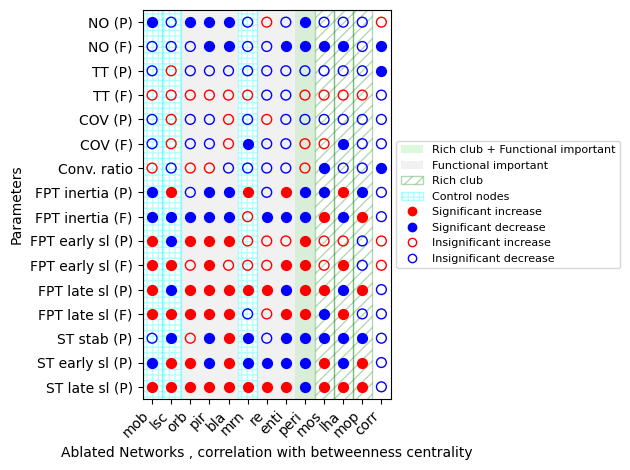

In [70]:
fig, ax = plt.subplots()
# Set up ticks and labels
ax.set_xticks(list(range(1,14)))
ax.set_xticklabels(["mob","lsc","orb","pir","bla","mrn","re","enti",
                    "peri","mos","lha","mop","corr"], 
                     rotation=45, ha='right')

ax.set_yticks(list(range(1,17)))
ax.set_yticklabels(['ST late sl (P)','ST early sl (P)','ST stab (P)',
                    'FPT late sl (F)','FPT late sl (P)',
                    'FPT early sl (F)','FPT early sl (P)',
                    'FPT inertia (F)','FPT inertia (P)',
                    'Conv. ratio','COV (F)','COV (P)','TT (F)',
                    'TT (P)','NO (F)','NO (P)'])

# shade green for rich club + functional important nodes  
for col in dict_irc.keys():
    ax.axvspan(dict_irc[col]-0.5, dict_irc[col]+0.5, facecolor='lightgreen', alpha=0.3)

# shade light grey for important nodes
for col in dict_fi.keys():
    ax.axvspan(dict_fi[col]-0.5, dict_fi[col]+0.5, facecolor='lightgrey', alpha=0.3)

# shade hatched green for rich club nodes
ymin, ymax = ax.get_ylim()  # full vertical span
for col in dict_rc.keys():
    rect = patches.Rectangle(
        (dict_rc[col]-0.5, ymin),        # bottom-left corner
        1.0,                             # width (one column)
        ymax - ymin+0.5,                     # height (full y-range)
        facecolor='none',                # no solid fill
        edgecolor='green',               # hatch color
        hatch='///',                     # hatch style
        alpha=0.3
    )
    ax.add_patch(rect)

# shade hatched cyan for control nodes
ymin, ymax = ax.get_ylim()  # full vertical span
for col in dict_cn.keys():
    rect = patches.Rectangle(
        (dict_cn[col]-0.5, ymin),        # bottom-left corner
        1.0,                             # width (one column)
        ymax - ymin+0.5,                 # height (full y-range)
        facecolor='none',                # no solid fill
        edgecolor='cyan',                # hatch color
        hatch='+++',                     # hatch style
        alpha=0.3
    )
    ax.add_patch(rect)

# NO part
draw_dots(no_p,16,ax=ax)

# NO full
draw_dots(no_f,15,ax=ax)

# TT (P)
draw_dots(tt_p,14,ax=ax)

# TT (F)
draw_dots(tt_f,13,ax=ax)

# COV (P)
draw_dots(cov_p,12,ax=ax)

# COV (F)
draw_dots(cov_f,11,ax=ax)

# conversion ratio (F/P)
draw_dots(con_r,10,ax=ax)

# Inertial part FPT
draw_dots(j_pfpt,9,ax=ax)

# Inertia full FPT
draw_dots(j_ffpt,8,ax=ax)

# Early slope  part FPT
draw_dots(e1_pfpt,7,ax=ax)

# Early slope  full FPT
draw_dots(e1_ffpt,6,ax=ax)

# Late slope  part FPT
draw_dots(e2_pfpt,5,ax=ax)

# Late slope  full FPT
draw_dots(e2_ffpt,4,ax=ax)

# Stabilization time st
draw_dots(j_pst,3,ax=ax)

# Early slope part ST
draw_dots(e1_pst,2,ax=ax)

# Late slope  full FPT
draw_dots(e2_pst,1,ax=ax)


# plot correlation with centrality
#NO P
ax.scatter(13, 16, s=50, facecolors='none',marker='o',edgecolors='red')
ax.scatter(13, 15, s=50, facecolors='blue',marker='o',edgecolors='blue')
ax.scatter(13, 14, s=50, facecolors='blue',marker='o',edgecolors='blue')
ax.scatter(13, 13, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 12, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 11, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 10, s=50, facecolors='blue',marker='o',edgecolors='blue')
ax.scatter(13, 9, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 8, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 7, s=50, facecolors='none',marker='o',edgecolors='red')
ax.scatter(13, 6, s=50, facecolors='none',marker='o',edgecolors='red')
ax.scatter(13, 5, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 4, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 3, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 2, s=50, facecolors='none',marker='o',edgecolors='blue')
ax.scatter(13, 1, s=50, facecolors='none',marker='o',edgecolors='blue')

ax.set_xlim(0.5, 13.5)
ax.set_ylim(0.5, 16.5)


# --- Patch handles for shaded regions ---
handle_rc_fi = patches.Patch(facecolor='lightgreen', alpha=0.3, label='Rich club + Functional important')
handle_fi    = patches.Patch(facecolor='lightgrey', alpha=0.3, label='Functional important')
handle_rc    = patches.Patch(facecolor='none', edgecolor='green', hatch='///', alpha=0.3, label='Rich club')
handle_cn    = patches.Patch(facecolor='none', edgecolor='cyan', hatch='+++', alpha=0.3, label='Control nodes')

# --- Marker handles for scatter dots ---
handle_inc_sig = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                               markersize=6, label='Significant increase')
handle_dec_sig = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                               markersize=6, label='Significant decrease')
handle_inc_ns  = mlines.Line2D([], [], color='red', marker='o', markerfacecolor='none',
                               linestyle='None', markersize=6, label='Insignificant increase')
handle_dec_ns  = mlines.Line2D([], [], color='blue', marker='o', markerfacecolor='none',
                               linestyle='None', markersize=6, label='Insignificant decrease')

# --- Combine all handles ---
legend_handles = [handle_rc_fi, handle_fi, handle_rc, handle_cn,
                  handle_inc_sig, handle_dec_sig, handle_inc_ns, handle_dec_ns]

# Place legend outside the plot (to the right)
ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

ax.set_xlabel('Ablated Networks , correlation with betweenness centrality')
ax.set_ylabel('Parameters')


plt.tight_layout()
plt.show()


Marking correlation

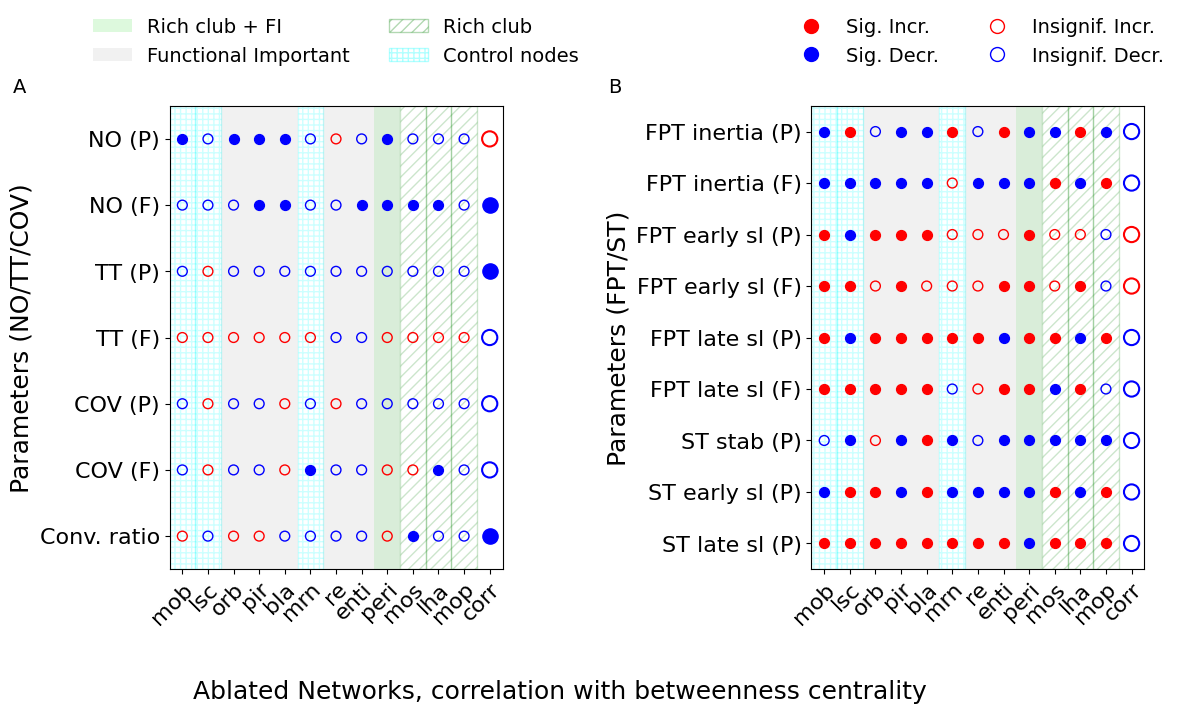

In [75]:


# --- INCREASED FONT SIZES ---
tick_fs = 16    # Axis tick labels
label_fs = 18   # X/Y Axis titles
legend_fs = 14  # Legend text
dot_size = 120  # Size for scatter points (s)
m_size = 10     # Size for legend markers (markersize)

# Figure width remains 16, height 6 for a balance of compact rows + large text
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 8), sharex=True)

# --- X ticks (shared) ---
xticks = ["mob","lsc","orb","pir","bla","mrn","re","enti",
          "peri","mos","lha","mop","corr"]

for ax in (ax_left, ax_right):
    ax.set_xticks(list(range(1, len(xticks) + 1)))
    # ax.set_xticklabels(xticks, rotation=45, ha='right', fontsize=tick_fs)
    ax.set_xticklabels(xticks, rotation=45, ha='right', rotation_mode='anchor', fontsize=tick_fs)

# --- Y labels ---
labels_left = ['NO (P)','NO (F)','TT (P)','TT (F)','COV (P)','COV (F)','Conv. ratio']
labels_right = ['FPT inertia (P)','FPT inertia (F)',
                'FPT early sl (P)','FPT early sl (F)',
                'FPT late sl (P)','FPT late sl (F)',
                'ST stab (P)','ST early sl (P)','ST late sl (P)']

ax_left.set_yticks(list(range(1, len(labels_left) + 1)))
ax_left.set_yticklabels(labels_left[::-1], fontsize=tick_fs)

ax_right.set_yticks(list(range(1, len(labels_right) + 1)))
ax_right.set_yticklabels(labels_right[::-1], fontsize=tick_fs)

# --- Tighten Limits ---
ax_left.set_xlim(0.5, len(xticks) + 0.5)
ax_right.set_xlim(0.5, len(xticks) + 0.5)
ax_left.set_ylim(0.5, len(labels_left) + 0.5)
ax_right.set_ylim(0.5, len(labels_right) + 0.5)

# --- Shading Logic ---
for ax in (ax_left, ax_right):
    for col in dict_irc.keys():
        ax.axvspan(dict_irc[col]-0.5, dict_irc[col]+0.5, facecolor='lightgreen', alpha=0.3)
    for col in dict_fi.keys():
        ax.axvspan(dict_fi[col]-0.5, dict_fi[col]+0.5, facecolor='lightgrey', alpha=0.3)

    ymin, ymax = ax.get_ylim()
    for col in dict_rc.keys():
        rect = patches.Rectangle((dict_rc[col]-0.5, ymin), 1.0, ymax-ymin,
                                 facecolor='none', edgecolor='green', hatch='///', alpha=0.2)
        ax.add_patch(rect)
    for col in dict_cn.keys():
        rect = patches.Rectangle((dict_cn[col]-0.5, ymin), 1.0, ymax-ymin,
                                 facecolor='none', edgecolor='cyan', hatch='+++', alpha=0.2)
        ax.add_patch(rect)

# --- Draw Dots & Corr Column ---
corr_idx = 13 

# Left Panel (Apply dot_size to your draw_dots function if it supports it)
draw_dots(no_p, 7, ax=ax_left) 
ax_left.scatter(corr_idx, 7, s=dot_size, facecolors='none', marker='o', edgecolors='red', linewidth=1.5)
draw_dots(no_f, 6, ax=ax_left)
ax_left.scatter(corr_idx, 6, s=dot_size, facecolors='blue', marker='o', edgecolors='blue')
draw_dots(tt_p, 5, ax=ax_left)
ax_left.scatter(corr_idx, 5, s=dot_size, facecolors='blue', marker='o', edgecolors='blue')
draw_dots(tt_f, 4, ax=ax_left)
ax_left.scatter(corr_idx, 4, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(cov_p, 3, ax=ax_left)
ax_left.scatter(corr_idx, 3, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(cov_f, 2, ax=ax_left)
ax_left.scatter(corr_idx, 2, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(con_r, 1, ax=ax_left)
ax_left.scatter(corr_idx, 1, s=dot_size, facecolors='blue', marker='o', edgecolors='blue')

# Right Panel
draw_dots(j_pfpt, 9, ax=ax_right)
ax_right.scatter(corr_idx, 9, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(j_ffpt, 8, ax=ax_right)
ax_right.scatter(corr_idx, 8, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(e1_pfpt, 7, ax=ax_right)
ax_right.scatter(corr_idx, 7, s=dot_size, facecolors='none', marker='o', edgecolors='red', linewidth=1.5)
draw_dots(e1_ffpt, 6, ax=ax_right)
ax_right.scatter(corr_idx, 6, s=dot_size, facecolors='none', marker='o', edgecolors='red', linewidth=1.5)
draw_dots(e2_pfpt, 5, ax=ax_right)
ax_right.scatter(corr_idx, 5, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(e2_ffpt, 4, ax=ax_right)
ax_right.scatter(corr_idx, 4, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(j_pst, 3, ax=ax_right)
ax_right.scatter(corr_idx, 3, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(e1_pst, 2, ax=ax_right)
ax_right.scatter(corr_idx, 2, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)
draw_dots(e2_pst, 1, ax=ax_right)
ax_right.scatter(corr_idx, 1, s=dot_size, facecolors='none', marker='o', edgecolors='blue', linewidth=1.5)

# --- Add Panel Labels (Top Right Outside) ---
ax_left.text(-0.43, 1.02, 'A', transform=ax_left.transAxes, fontsize=14, va='bottom', ha='right')
ax_right.text(-0.57, 1.02, 'B', transform=ax_right.transAxes, fontsize=14,  va='bottom', ha='right')


# --- Legends & Labels ---
handle_rc_fi = patches.Patch(facecolor='lightgreen', alpha=0.3, label='Rich club + FI')
handle_fi    = patches.Patch(facecolor='lightgrey', alpha=0.3, label='Functional Important')
handle_rc    = patches.Patch(facecolor='none', edgecolor='green', hatch='///', alpha=0.3, label='Rich club')
handle_cn    = patches.Patch(facecolor='none', edgecolor='cyan', hatch='+++', alpha=0.3, label='Control nodes')

handle_inc_sig = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=m_size, label='Sig. Incr.')
handle_dec_sig = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=m_size, label='Sig. Decr.')
handle_inc_ns  = mlines.Line2D([], [], color='red', marker='o', markerfacecolor='none', linestyle='None', markersize=m_size, label='Insignif. Incr.')
handle_dec_ns  = mlines.Line2D([], [], color='blue', marker='o', markerfacecolor='none', linestyle='None', markersize=m_size, label='Insignif. Decr.')

ax_left.legend(handles=[handle_rc_fi, handle_fi, handle_rc, handle_cn], 
               loc='lower center', bbox_to_anchor=(0.5, 1.05), fontsize=legend_fs, ncol=2, frameon=False)
ax_right.legend(handles=[handle_inc_sig, handle_dec_sig, handle_inc_ns, handle_dec_ns], 
                loc='lower center', bbox_to_anchor=(0.5, 1.05), fontsize=legend_fs, ncol=2, frameon=False)

ax_left.set_ylabel('Parameters (NO/TT/COV)', fontsize=label_fs)
ax_right.set_ylabel('Parameters (FPT/ST)', fontsize=label_fs)
fig.text(0.5, 0.01, 'Ablated Networks, correlation with betweenness centrality', ha='center', fontsize=label_fs)

# Use rect to ensure the top legend and bottom text have breathing room
plt.tight_layout(rect=[0, 0.08, 1, 0.90])
plt.show()

#### Making data fpr fig 5I,J

In [81]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value

Slope 2 of full fpt

In [8]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(d['full_fpt'].index)
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = d['full_fpt']['exp2']['fn']
ref_se = d['full_fpt']['exp2_se']['fn']

for s, se in zip(d['full_fpt']['exp2'], d['full_fpt']['exp2_se']):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
nw = []

# Clean Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # Prints everything beautifully aligned in fixed-width text columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (d['full_fpt']) ---")
print(nw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -6.6019      | 4.0601e-11   | 2.8421e-10   | True        
enti            | -11.5253     | 0.0000e+00   | 0.0000e+00   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | -5.1726      | 2.3092e-07   | 1.1546e-06   | True        
lsc             | -6.5518      | 5.6833e-11   | 3.4100e-10   | True        
mob             | -7.7933      | 6.4393e-15   | 6.4393e-14   | True        
mop             | 0.9090       | 3.6336e-01   | 7.2673e-01   | False       
mos             | 7.2533       | 4.0679e-13   | 3.2543e-12   | True        
mrn             | 1.2604       | 2.0753e-01   | 6.2258e-01   | False       
orb             | -7.3764      | 1.6276e-13   | 1.4648e-12   | True        
peri            | -14.3077     | 0.0000e+00   | 0.0000e+00   | True        
pir            

In [9]:
full_fpt={'slp2':dict(zip(d['full_fpt']['exp2'].index,d['full_fpt']['exp2'])),'s_nw':nw}
full_fpt

{'slp2': {'bla': -0.015621400946970582,
  'enti': -0.011870706614842892,
  'fn': -0.023825489979522677,
  'lha': -0.016637853616258948,
  'lsc': -0.01660086964388635,
  'mob': -0.015648301449715372,
  'mop': -0.025236036098091427,
  'mos': -0.06191159879228881,
  'mrn': -0.025648837552136317,
  'orb': -0.016159770412654643,
  'peri': -0.009226023236027288,
  'pir': -0.01061998704563124,
  're': -0.021231212654022016},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'mos', 'orb', 'peri', 'pir']}

Slope 2 of part FPT

In [10]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(d['part_fpt'].index)
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = d['part_fpt']['exp2']['fn']
ref_se = d['part_fpt']['exp2_se']['fn']

for s, se in zip(d['part_fpt']['exp2'], d['part_fpt']['exp2_se']):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
nw = []

# Clean Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # Prints everything beautifully aligned in fixed-width text columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (d['part_fpt']) ---")
print(nw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -18.2298     | 0.0000e+00   | 0.0000e+00   | True        
enti            | 4.9539       | 7.2755e-07   | 3.6377e-06   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | 6.3931       | 1.6256e-10   | 1.1379e-09   | True        
lsc             | 11.1931      | 0.0000e+00   | 0.0000e+00   | True        
mob             | -9.7078      | 0.0000e+00   | 0.0000e+00   | True        
mop             | -19.9205     | 0.0000e+00   | 0.0000e+00   | True        
mos             | -18.2421     | 0.0000e+00   | 0.0000e+00   | True        
mrn             | -2.0563      | 3.9755e-02   | 7.9511e-02   | False       
orb             | -3.8723      | 1.0781e-04   | 3.2342e-04   | True        
peri            | -5.1537      | 2.5534e-07   | 1.5320e-06   | True        
pir            

In [11]:
part_fpt={'slp2':dict(zip(d['part_fpt']['exp2'].index,d['part_fpt']['exp2'])),'s_nw':nw}
part_fpt

{'slp2': {'bla': -0.01671800273183915,
  'enti': -0.040905439288291615,
  'fn': -0.03345828659877381,
  'lha': -0.04825150736861619,
  'lsc': -0.05207141985696865,
  'mob': -0.023691570678493944,
  'mop': -0.015711894701390967,
  'mos': -0.01699425388959476,
  'mrn': -0.0304749201513648,
  'orb': -0.029436935922990928,
  'peri': -0.026694991844799485,
  'pir': -0.01565270186625166,
  're': -0.028613500654358914},
 's_nw': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'orb',
  'peri',
  'pir',
  're']}

Slope 2 of part ST

In [12]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(d['part_st'].index)
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = d['part_st']['exp2']['fn']
ref_se = d['part_st']['exp2_se']['fn']

for s, se in zip(d['part_st']['exp2'], d['part_st']['exp2_se']):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
nw = []

# Clean Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # Prints everything beautifully aligned in fixed-width text columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (d['part_st']) ---")
print(nw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -27.7928     | 0.0000e+00   | 0.0000e+00   | True        
enti            | -16.7303     | 0.0000e+00   | 0.0000e+00   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | -13.6626     | 0.0000e+00   | 0.0000e+00   | True        
lsc             | -17.1959     | 0.0000e+00   | 0.0000e+00   | True        
mob             | -18.3761     | 0.0000e+00   | 0.0000e+00   | True        
mop             | -15.1360     | 0.0000e+00   | 0.0000e+00   | True        
mos             | -20.3166     | 0.0000e+00   | 0.0000e+00   | True        
mrn             | -11.8292     | 0.0000e+00   | 0.0000e+00   | True        
orb             | -5.6191      | 1.9196e-08   | 5.7588e-08   | True        
peri            | 15.7931      | 0.0000e+00   | 0.0000e+00   | True        
pir            

In [13]:
part_st={'slp2':dict(zip(d['part_st']['exp2'].index,d['part_st']['exp2'])),'s_nw':nw}
part_st

{'slp2': {'bla': -0.0037638777491341754,
  'enti': -0.008080481741196747,
  'fn': -0.013741613448875192,
  'lha': -0.00793552502116648,
  'lsc': -0.00791426787895185,
  'mob': -0.006034022604791975,
  'mop': -0.008587630768872413,
  'mos': -0.006895724231832579,
  'mrn': -0.009443681370365534,
  'orb': -0.011018177058450238,
  'peri': -0.023834984767783663,
  'pir': -0.012222979849955276,
  're': -0.007972215755241159},
 's_nw': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'mrn',
  'orb',
  'peri',
  'pir',
  're']}

In [14]:
reader.data_dump_pkl('results/figures/fig5i_data.pkl',{'fpt_full':full_fpt,'fpt_part':part_fpt,'st_part':part_st})